# Compare RNA expression and GeneActivityScore across cell-types

In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)
library(scuttle)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==

In [2]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

## RNA pseudobulking per celltype

In [7]:
# Load RNA
io$RNA_in <- file.path(io$basedir,"RNA/RangedSummarizedExperiment.rds")
sceRNA = readRDS(io$RNA_in)

In [8]:
sceRNA

class: RangedSummarizedExperiment 
dim: 20845 146133 
metadata(0):
assays(1): counts
rownames(20845): WDR31 RNF183 ... ENSOCUG00000014718 ENSOCUG00000019471
rowData names(2): gene_id symbol
colnames(146133): cell_1 cell_2 ... cell_172994 cell_172995
colData names(25): cell cell ... somite_count stage

In [9]:
sce_pseudobulk <- aggregateAcrossCells(sceRNA, id=sceRNA$celltype, BPPARAM = BPPARAM)

In [10]:
assayNames(sce_pseudobulk) <- "counts"
sce_pseudobulk@assays@data$logcounts <- log2(1e6*(sweep(sce_pseudobulk@assays@data$counts,2,colSums(sce_pseudobulk@assays@data$counts),"/"))+1)

In [11]:
rna.mtx = sce_pseudobulk@assays@data$logcounts

#### RNA marker gene detection
To compare RNA expression with gene accessibility

In [ ]:
# RNA marker gene detection
summed <- aggregateAcrossCells(sceRNA, 
                               id=colData(sceRNA)[,c("celltype", "sample")],
                               BPPARAM = BPPARAM)
summed

In [ ]:
library(scran)

In [ ]:
RNA_all_markers = mclapply(unique(summed$celltype), function(x){
    summed$test = ifelse(summed$celltype == x, 'group', 'background')

    between.res <- pseudoBulkDGE(summed,
        label=rep("dummy", ncol(summed)),
        design=~factor(sample) + test,
        coef="testgroup")[[1]]

    RNA_markers = as.data.table(between.res, keep.rownames=T) %>% 
        setnames('rn', 'gene') %>%
        .[,celltype:=x] %>%
        .[logFC>1 & FDR<0.05] %>% 
        .[order(-logFC)] 

    return(RNA_markers)
}, mc.cores=16) %>% rbindlist(.)

In [ ]:
unique(summed$celltype)[!unique(summed$celltype) %in% unique(RNA_all_markers$celltype)]

In [65]:
fwrite(RNA_all_markers, '/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/celltype_markers.txt.gz')

## ATAC pseudobulking per celltype

In [12]:
# retrieve gene score matrix
gene_counts = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "GeneScoreMatrix",
  binarize = FALSE,
  threads = getArchRThreads())

In [13]:
assayNames(gene_counts) <- "counts"

In [161]:
saveRDS(gene_counts, sprintf('%s/GeneScoreMatrix.rds', io$archR.directory))

In [4]:
gene_counts = readRDS(sprintf('%s/GeneScoreMatrix.rds', io$archR.directory))

In [5]:
# aggregate mean of GeneScoreMatrix per mapped celltype
gene_counts_pseudobulk <- aggregateAcrossCells(gene_counts, id=gene_counts$predictedGroup_celltype_PeakMatrix, statistics = 'mean', BPPARAM = BPPARAM)

In [6]:
# extract matrix
atac.mtx = gene_counts_pseudobulk@assays@data$counts
rownames(atac.mtx) = rowData(gene_counts_pseudobulk)$name

# RNA - ATAC correlation
Based on marker genes detected in RNA using edgeR (one vs all)

In [12]:
RNA_all_markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/celltype_markers.txt.gz')

In [13]:
# subset to shared cell-types
#ct_keep = intersect(colnames(rna.mtx), colnames(atac.mtx))

# excl celltypes with too few cells
meta = as.data.table(ArchRProject@cellColData)
cell_nr = as.data.table(meta) %>% .[,N:=.N, by='predictedGroup_celltype_PeakMatrix'] %>% unique(by='predictedGroup_celltype_PeakMatrix') %>% .[,c('predictedGroup_celltype_PeakMatrix', 'N')]
ct_keep = cell_nr[N>20, predictedGroup_celltype_PeakMatrix]
rna.mtx = rna.mtx[,ct_keep]
atac.mtx = atac.mtx[,ct_keep]

# Define function to correlate RNA - ATAC
corr_gene = function(gene, method='pearson', log2_atac=FALSE){ # log2 doesn't make a difference for spearman 
    if(log2_atac==TRUE){
        tmp = cor(rna.mtx[gene,], log2(atac.mtx[gene,]+1), method=method)
    }else{tmp = cor(rna.mtx[gene,], atac.mtx[gene,], method=method)}
    return(tmp)
}

In [14]:
# Global correlations based on markers, at different logFC thresholds
for(i in c(1,1.5,2,2.2,2.5,3)){
    print(i)
    gene_list = intersect(RNA_all_markers[logFC>i & FDR<0.05, gene], rownames(atac.mtx))
    
    print(paste0('spearman: ', round(mean(sapply(gene_list, corr_gene, method='spearman')),3),
                 ', pearson: ', round(mean(sapply(gene_list, corr_gene, method='pearson', log2_atac=F)),3),
                 ', pearson log2: ', round(mean(sapply(gene_list, corr_gene, method='pearson', log2_atac=T)),3)))
}

[1] 1
[1] "spearman: 0.292, pearson: 0.343, pearson log2: 0.343"
[1] 1.5
[1] "spearman: 0.351, pearson: 0.421, pearson log2: 0.42"
[1] 2
[1] "spearman: 0.376, pearson: 0.461, pearson log2: 0.458"
[1] 2.2
[1] "spearman: 0.379, pearson: 0.47, pearson log2: 0.467"
[1] 2.5
[1] "spearman: 0.381, pearson: 0.478, pearson log2: 0.474"
[1] 3
[1] "spearman: 0.374, pearson: 0.483, pearson log2: 0.478"


In [15]:
# Plot mean of celltype markers_tmp
options(repr.plot.width=25, repr.plot.height=5)

p = lapply(unique(RNA_all_markers$celltype), function(x){
        markers_tmp = RNA_all_markers[celltype==x] %>% 
            .[logFC>1] %>% 
            .[order(-logFC), gene] %>% head(50)
        markers_tmp = intersect(markers_tmp, rownames(atac.mtx))

        if(length(markers_tmp)>1){
            rna.tmp = data.table(celltype = colnames(rna.mtx), rna_counts = colMeans(rna.mtx[markers_tmp,]))
            atac.tmp =  data.table(celltype = colnames(atac.mtx), atac_counts = colMeans(atac.mtx[markers_tmp,]))

            merge = merge(rna.tmp, atac.tmp, by='celltype') %>%
                .[,`:=`(rna_counts = scale(rna_counts),
                        atac_counts = scale(atac_counts))]

    #        options(repr.plot.width=6, repr.plot.height=6)
            
            lm = lm(rna_counts ~ atac_counts, merge)
            

            ggplot(merge, aes(rna_counts, atac_counts)) + 
                geom_smooth(method='lm', col='black', alpha=0.5) + 
                geom_point(size=4, aes(col=celltype)) + 
            #    geom_abline(slope=1) + 
                scale_colour_manual(values=opts$celltype_colours) + 
                ggrepel::geom_text_repel(data=unique(rbind(head(merge[order(-rna_counts)], 5), head(merge[order(-atac_counts)], 5))), # label top 5 of atac & rna
                                         aes(label=celltype),
                                         box.padding=0.8) + 
                ggtitle(x,
                       paste('Corr:', round(cor(merge$rna_counts, merge$atac_counts, method='pearson'),2), 
                             '/ R2:', round(summary(lm)$r.squared,2), 
                             '/ number of genes =', length(markers_tmp))) + 
                xlab('gene expression') + ylab('gene accessibility') + 
                theme_bw() +
                theme(legend.position='none',
                      text=element_text(size=15, color='black'),
                      axis.text=element_text(color='black'))
    }
})

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using for

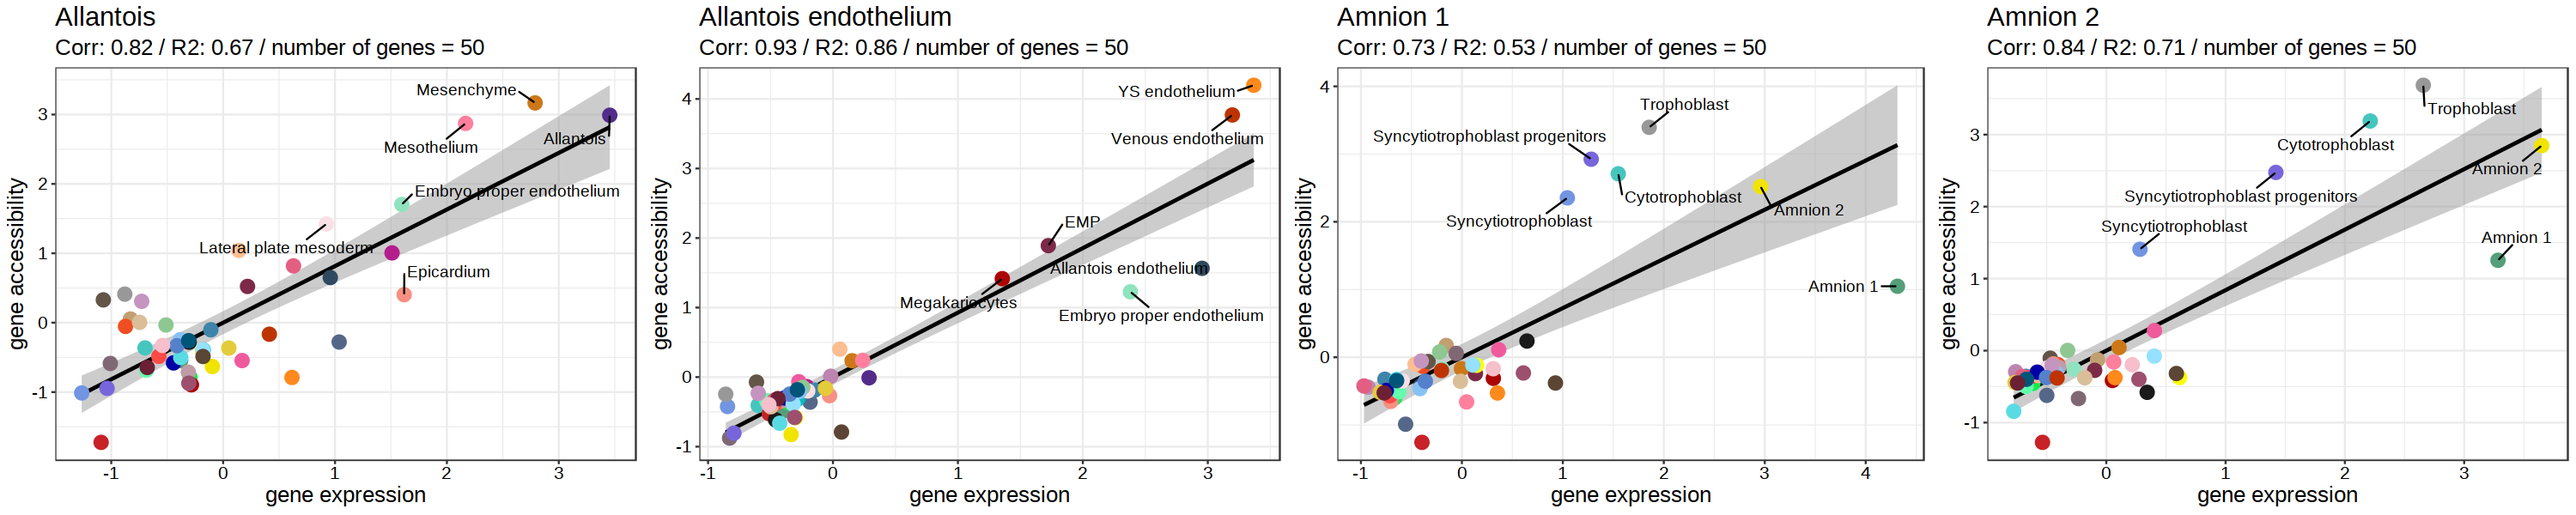

Warning message:
“ggrepel: 5 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


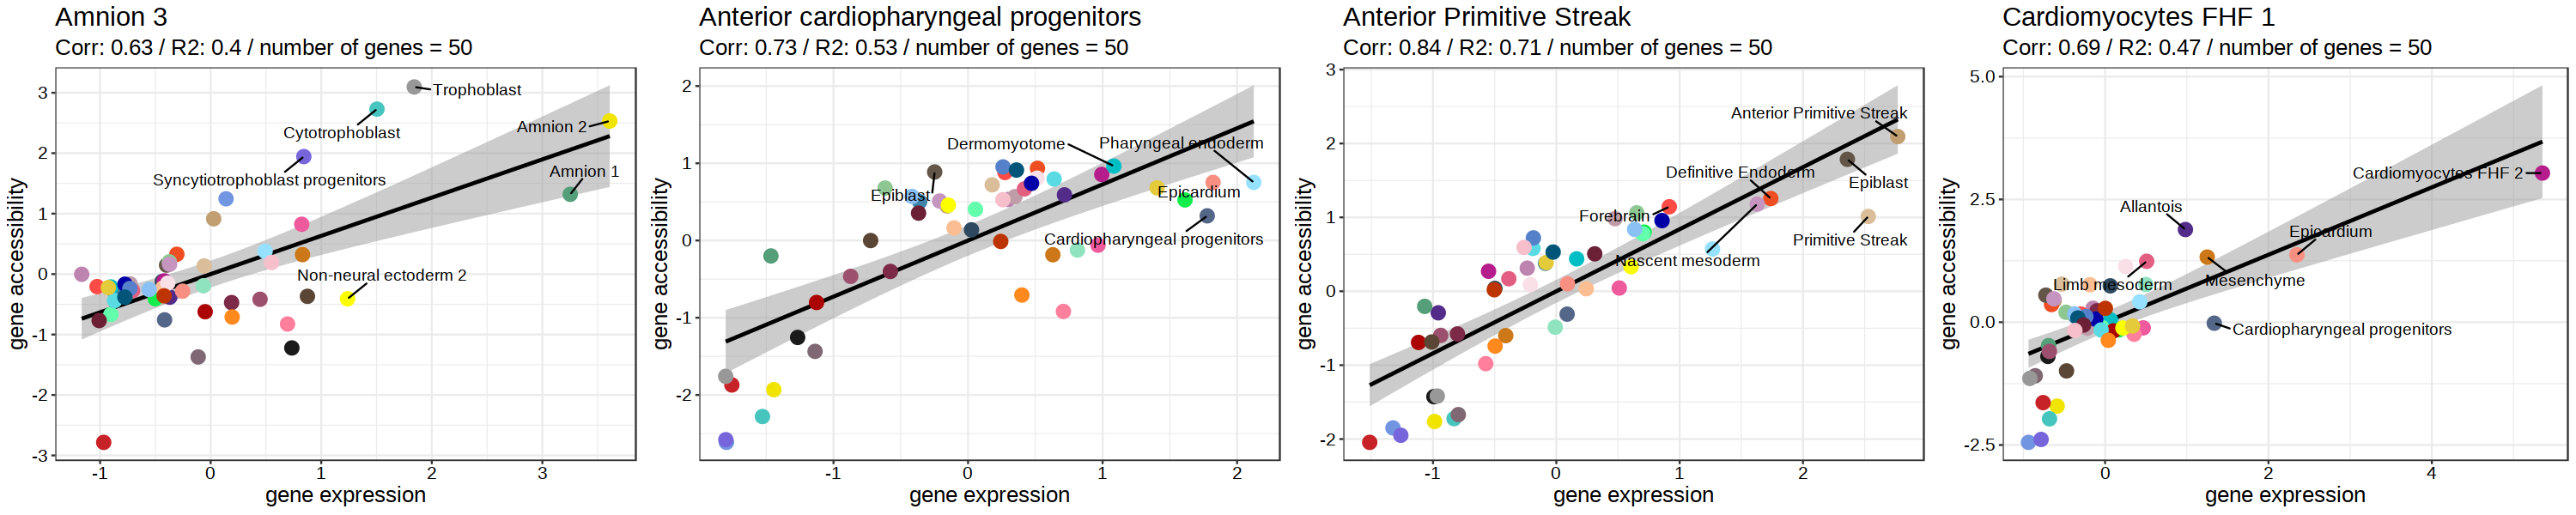

Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


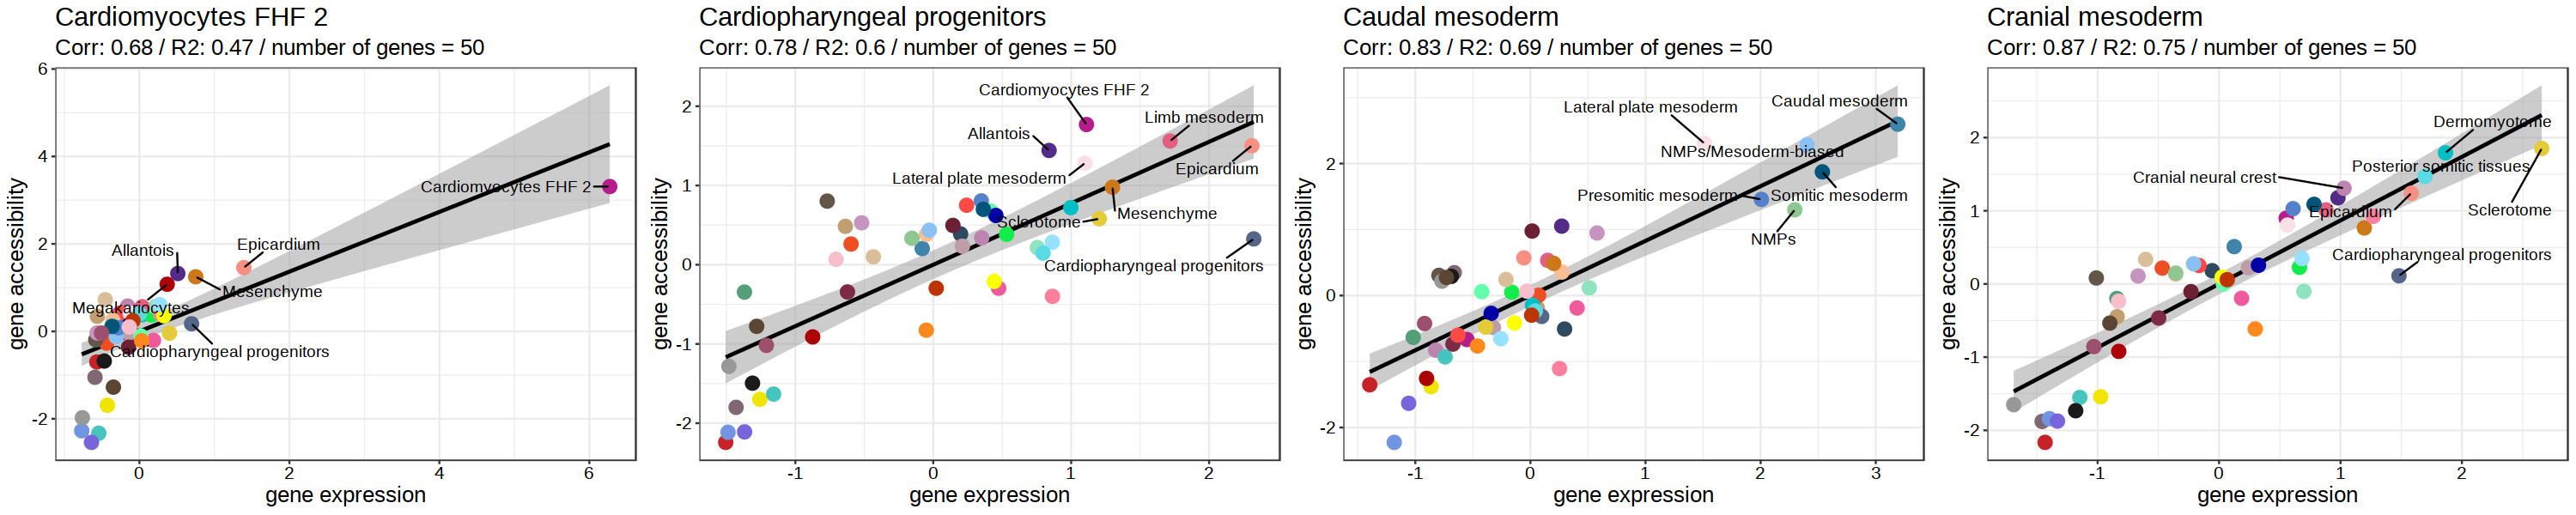

Warning message:
“ggrepel: 5 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


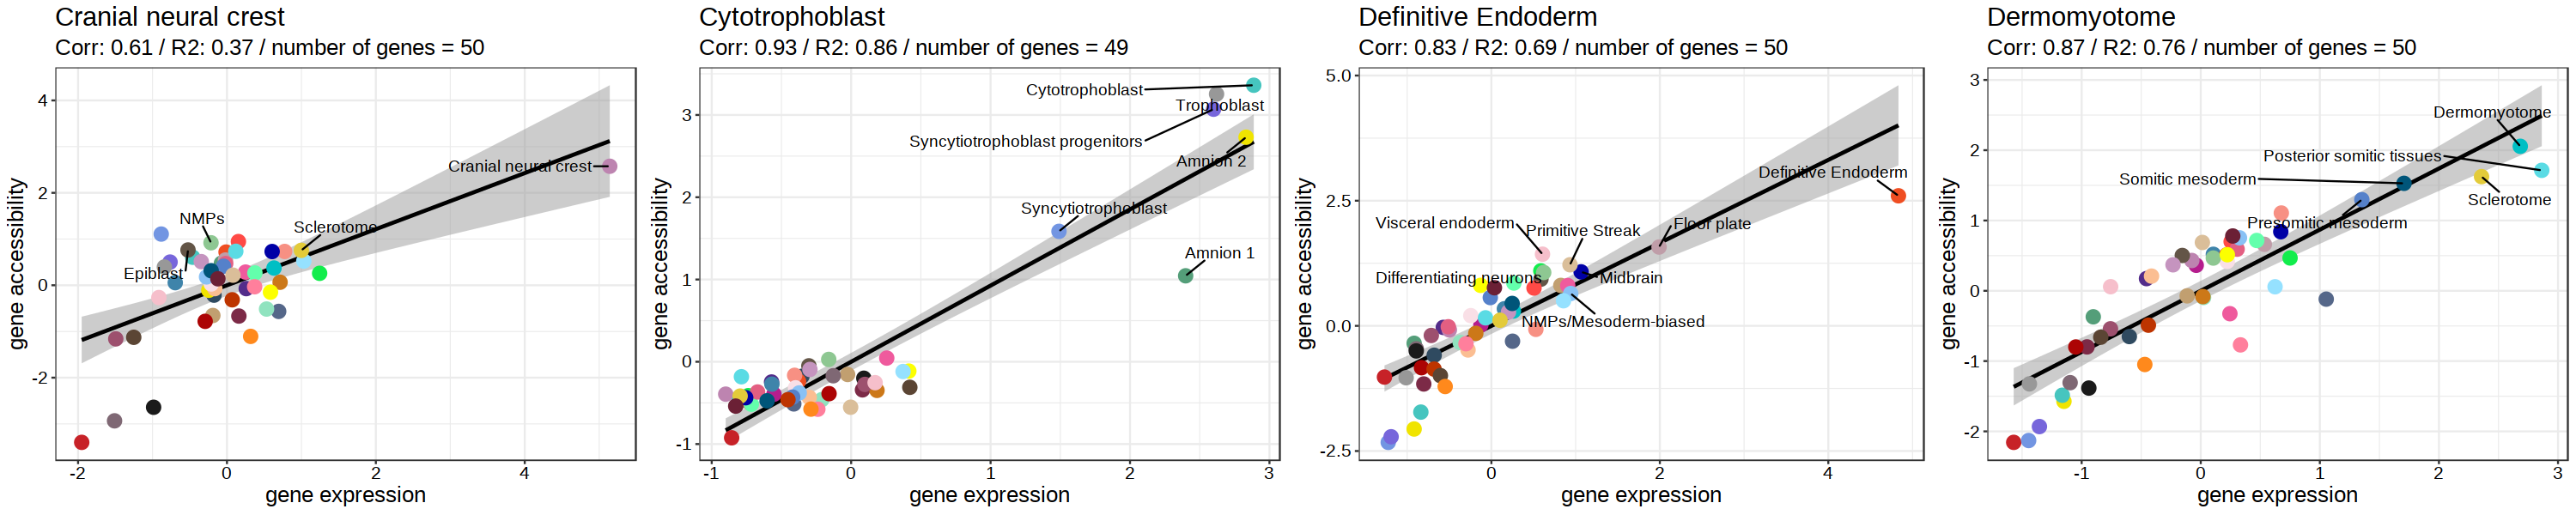

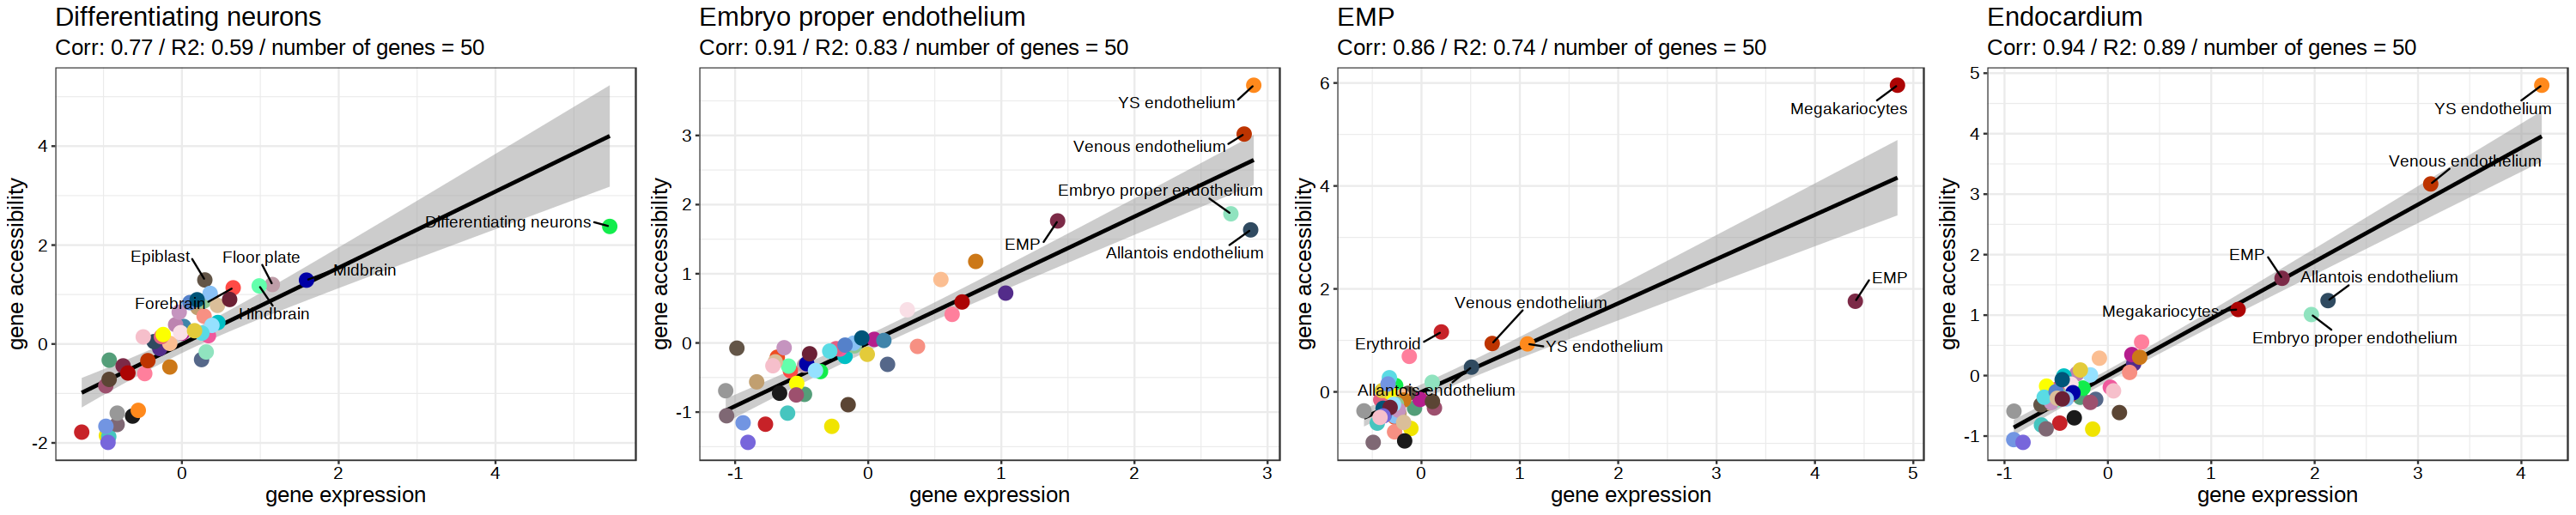

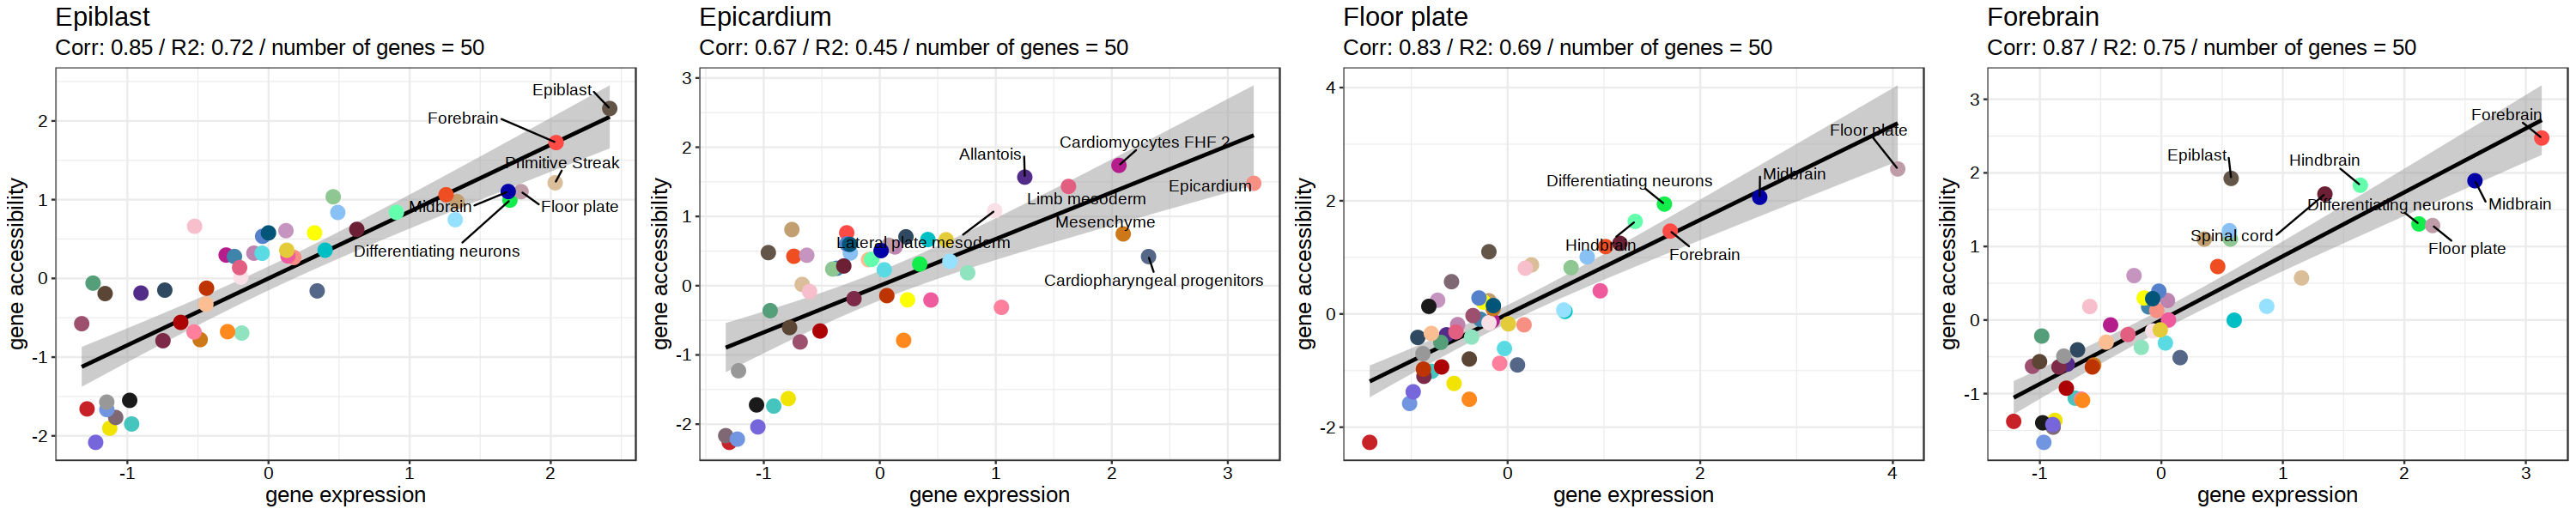

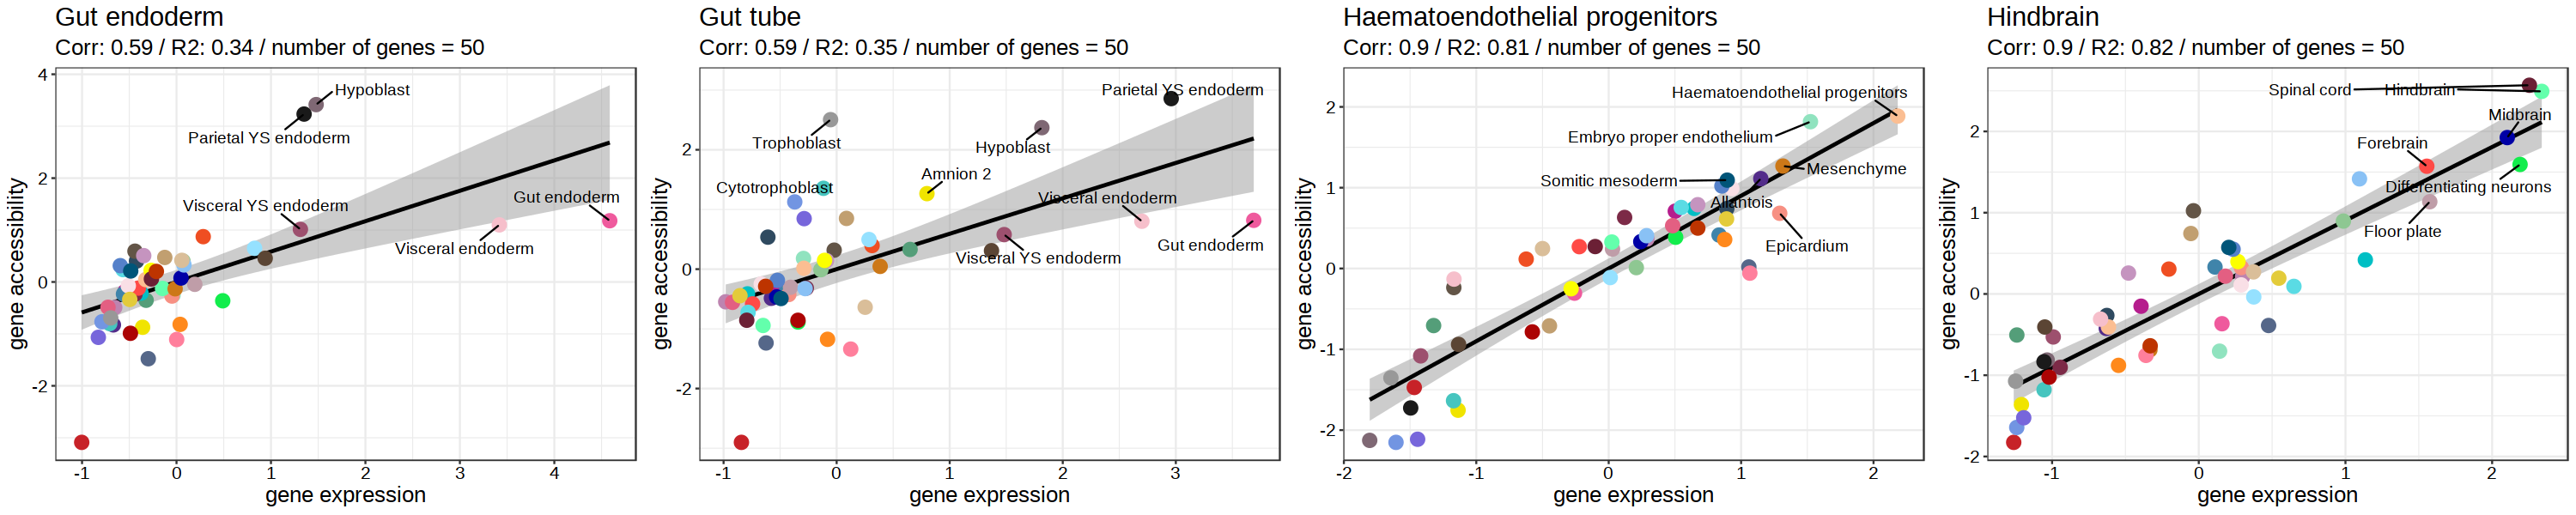

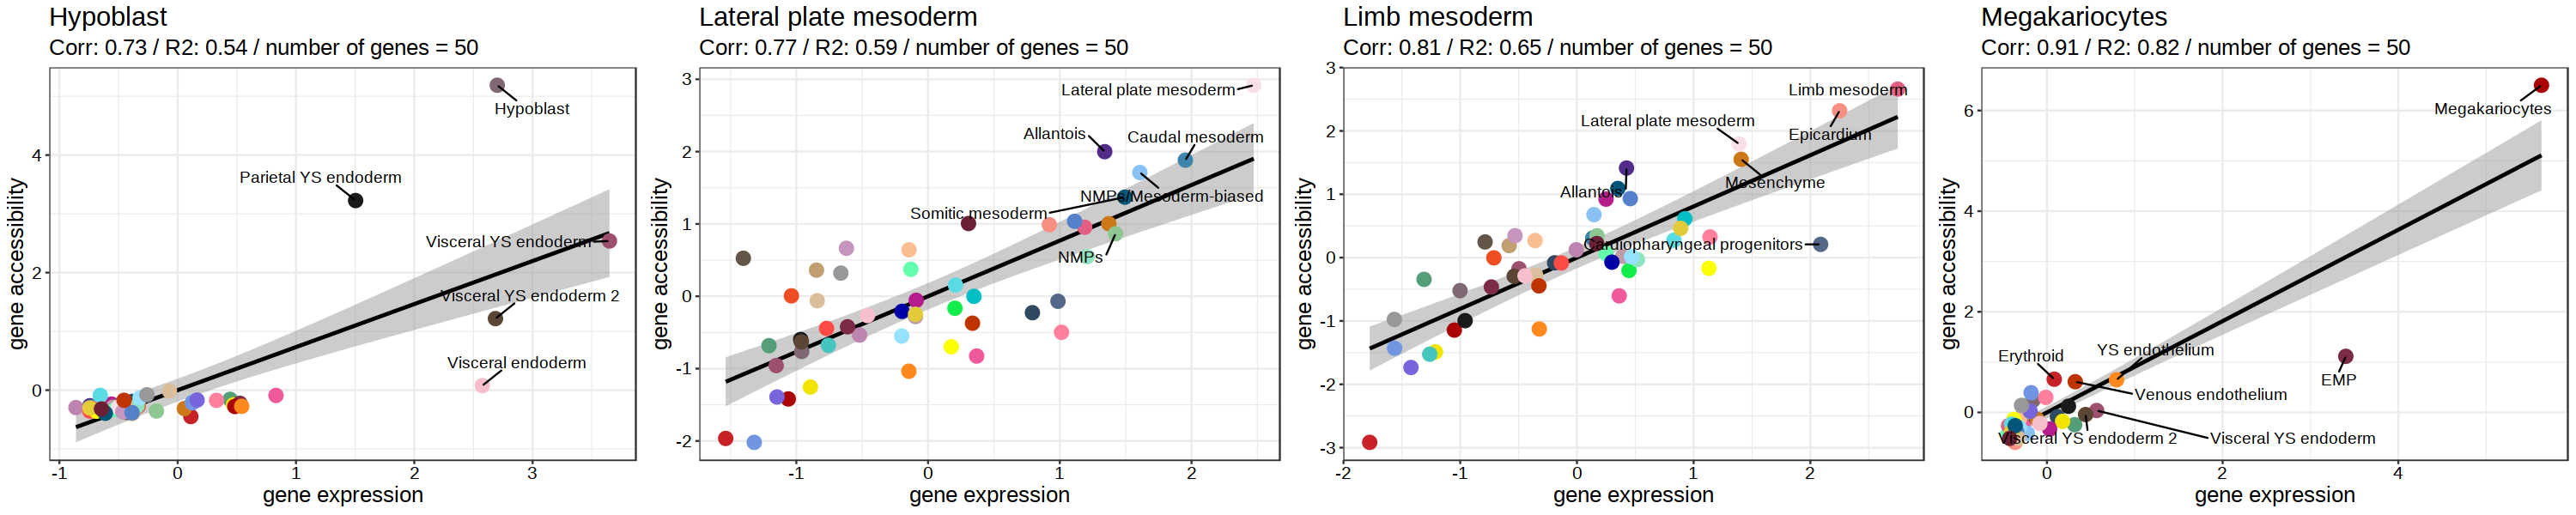

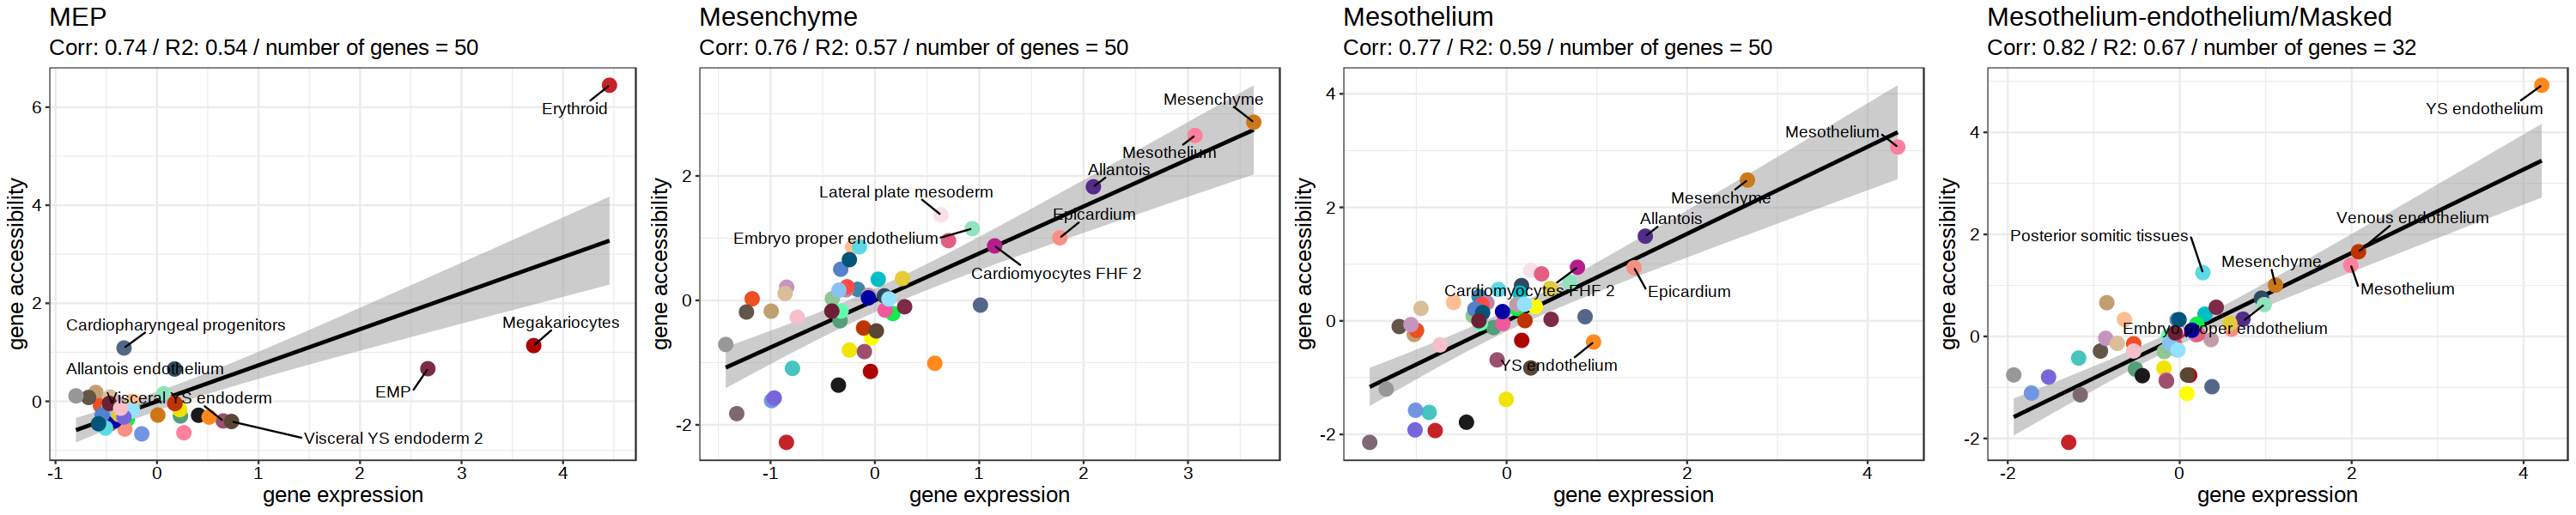

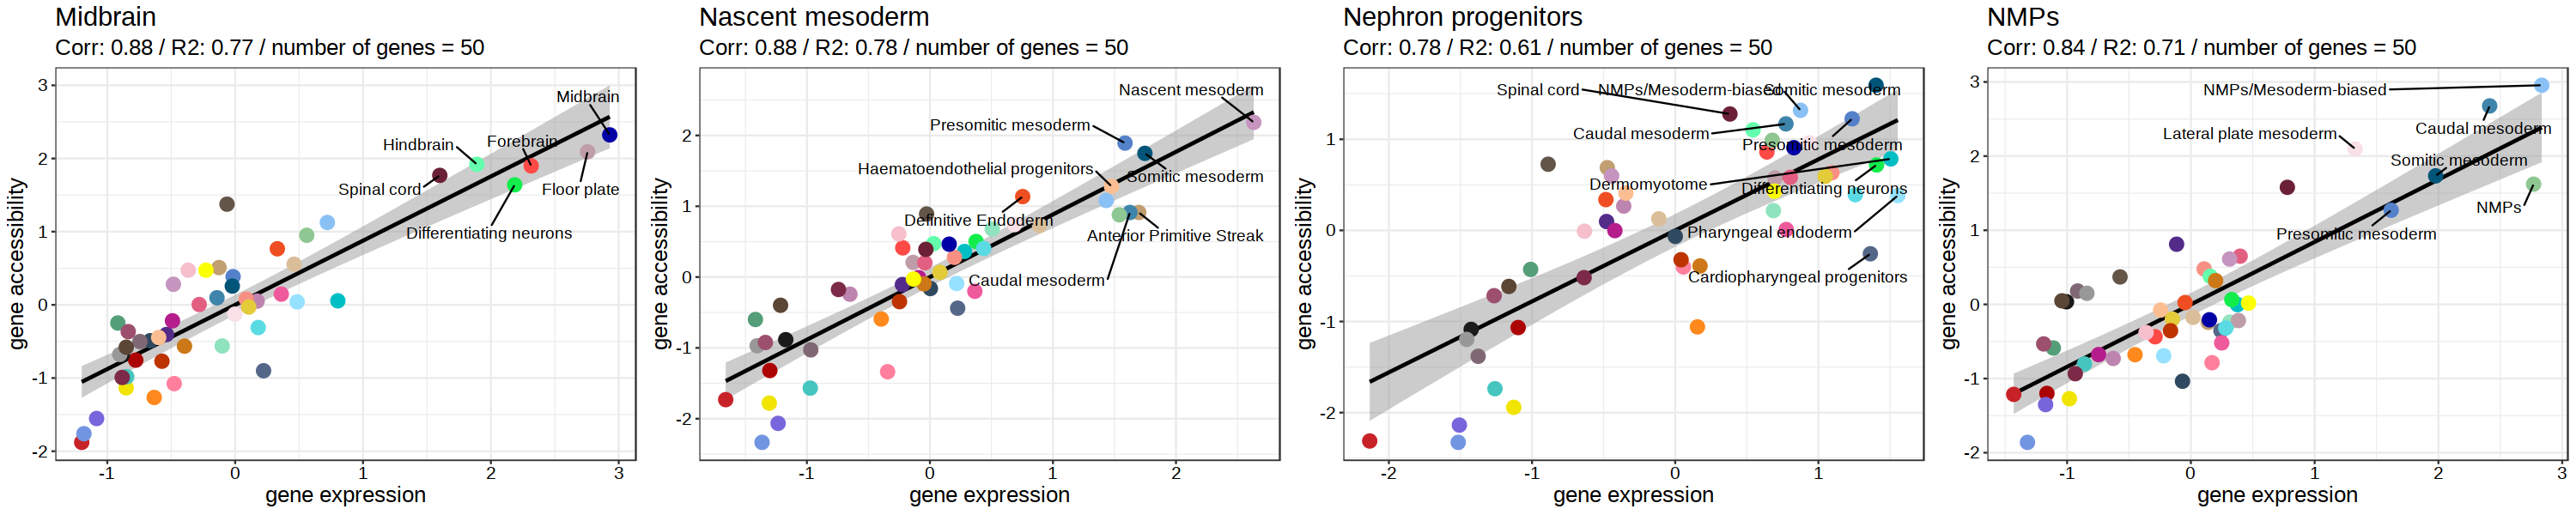

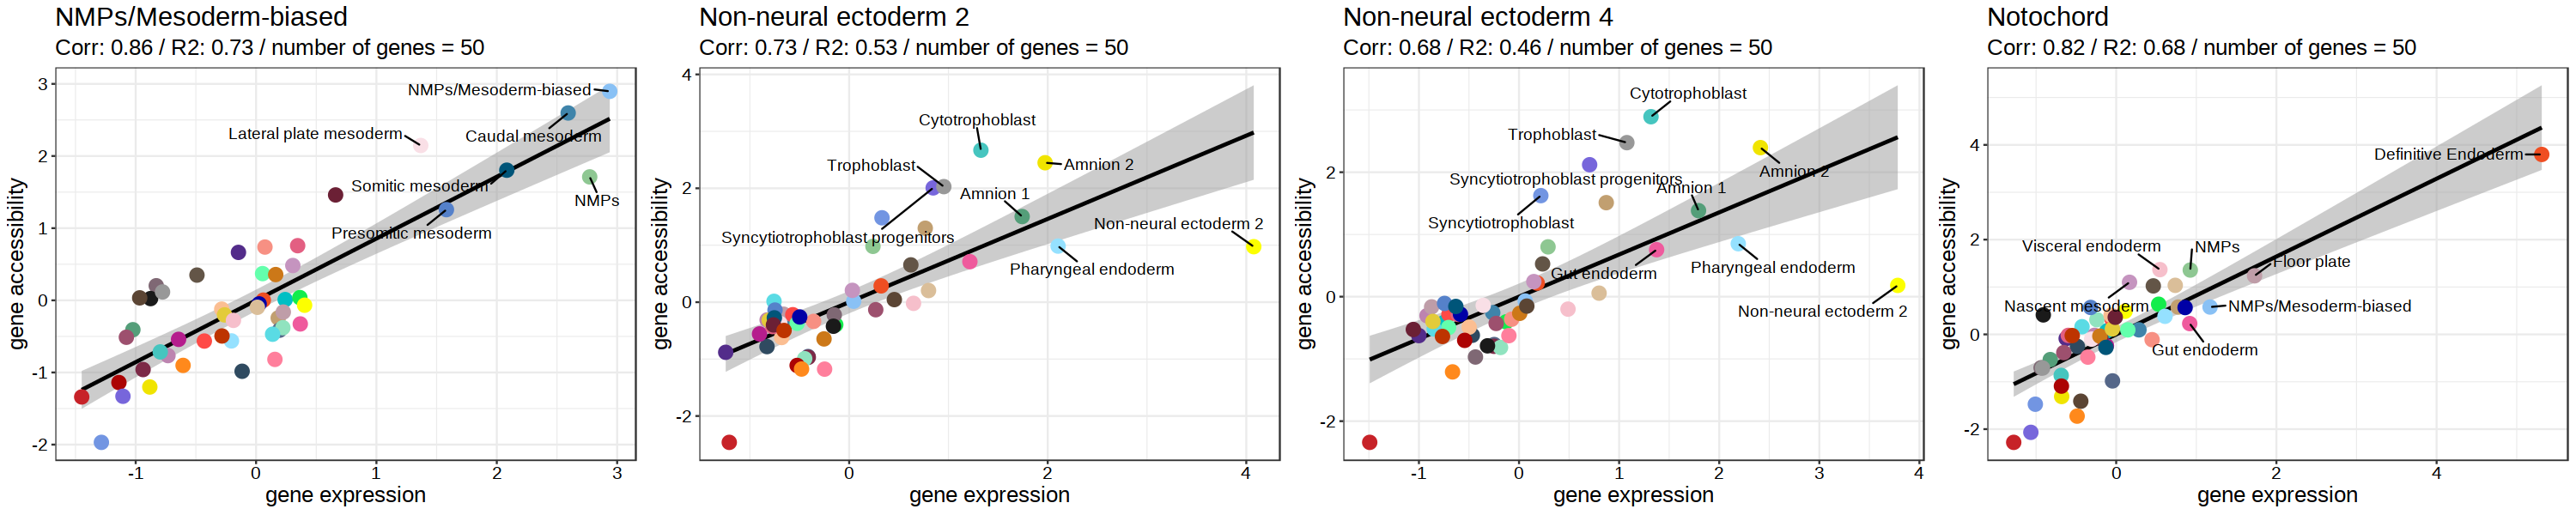

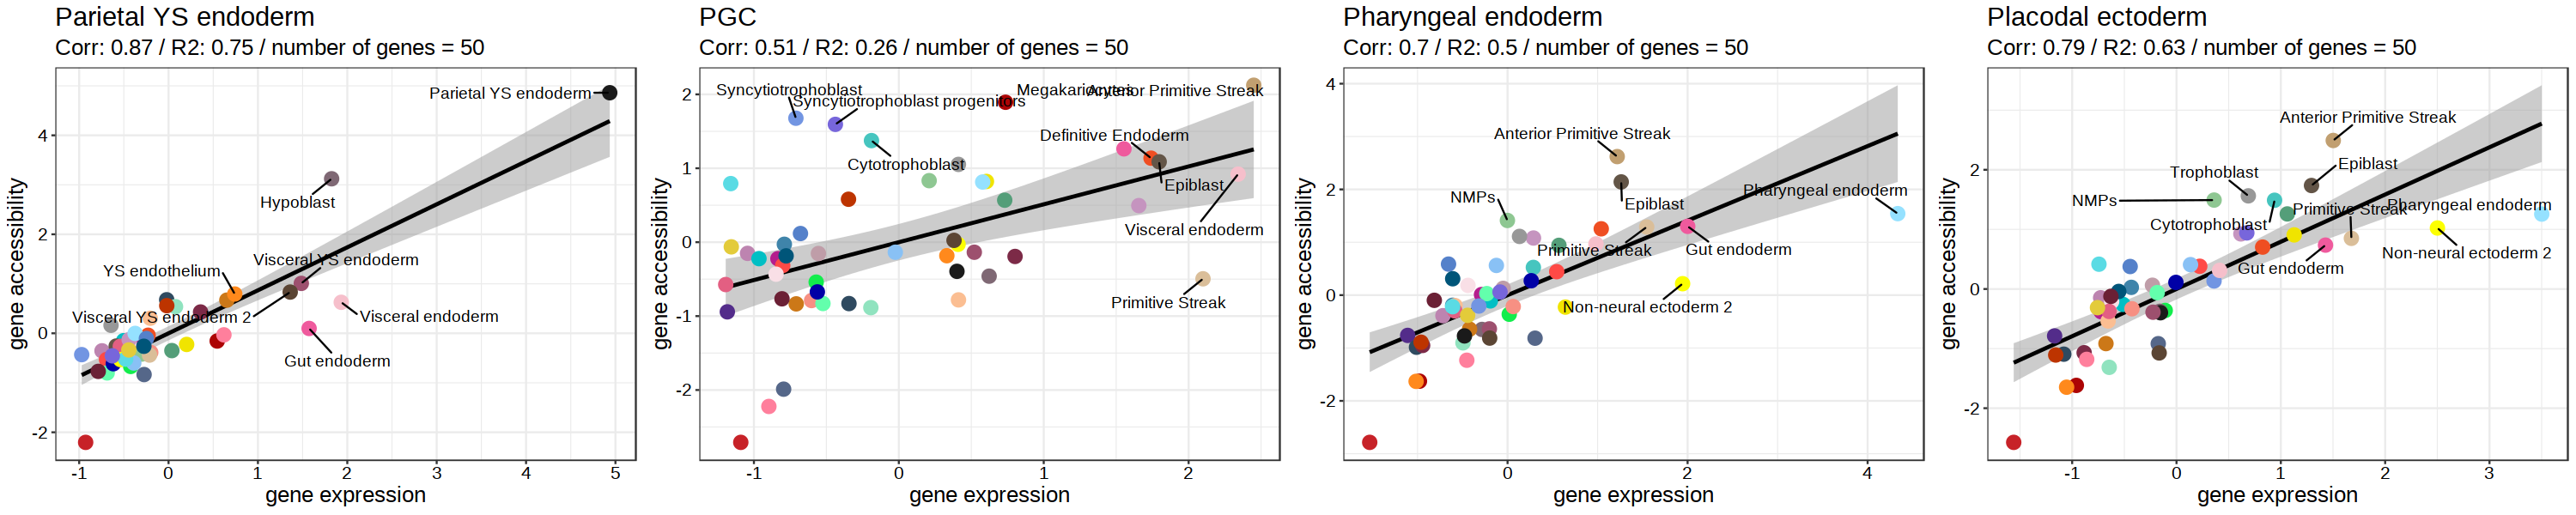

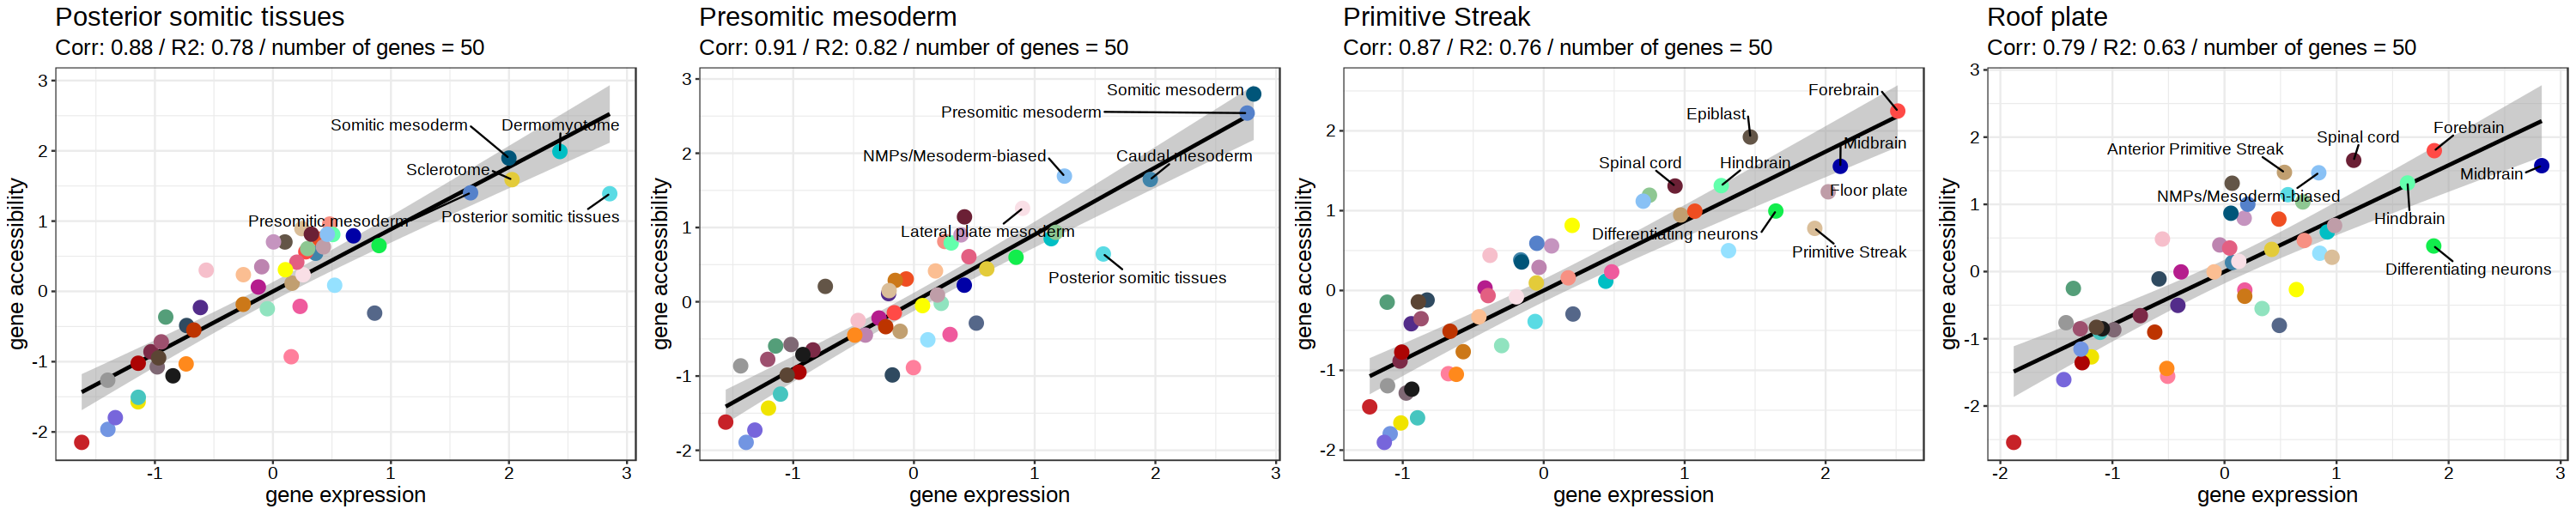

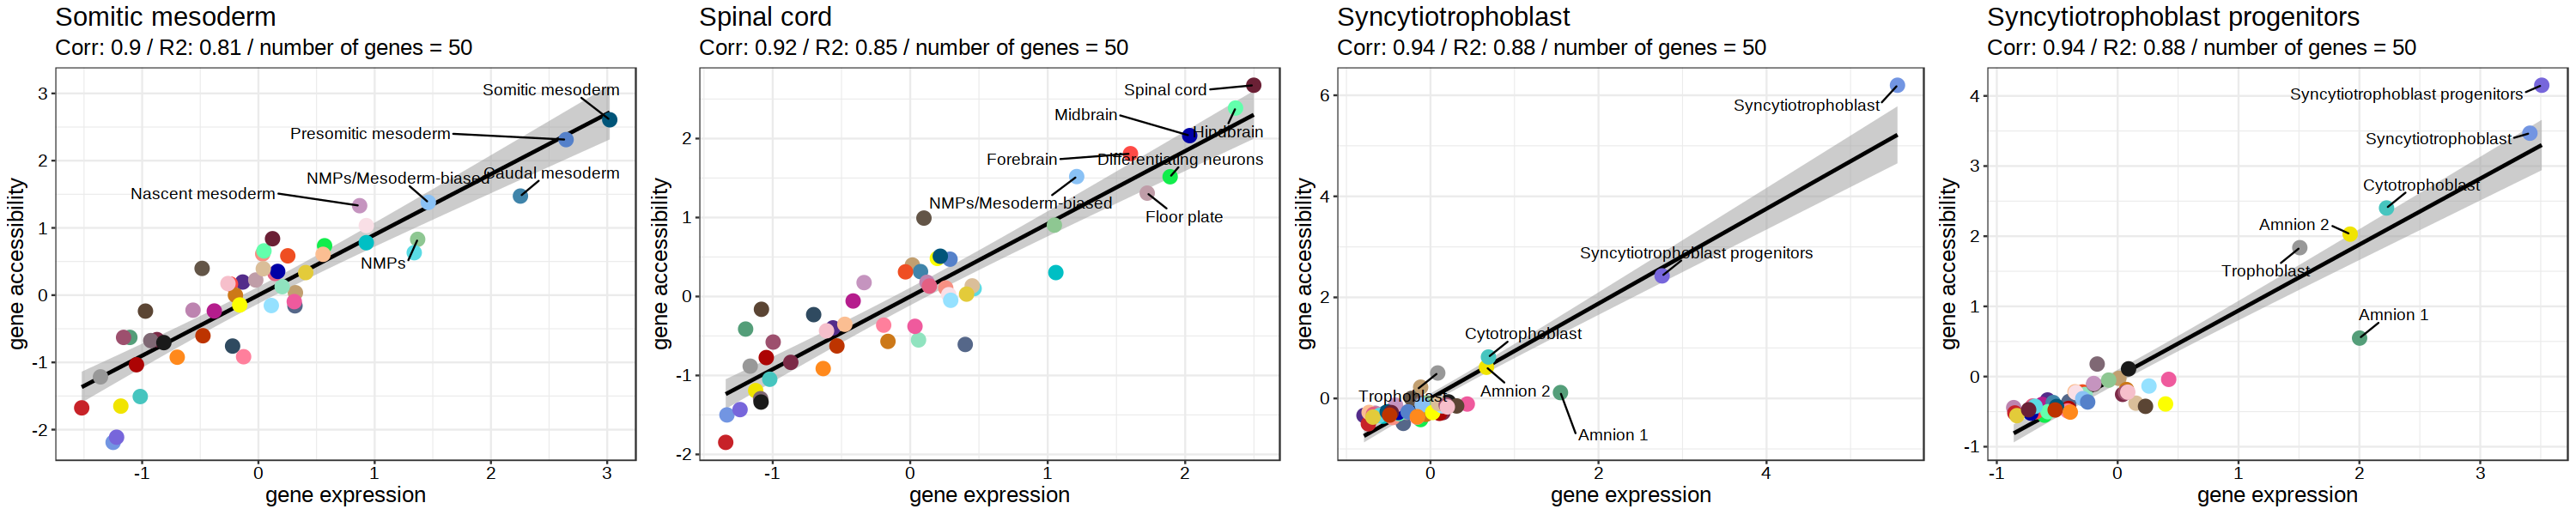

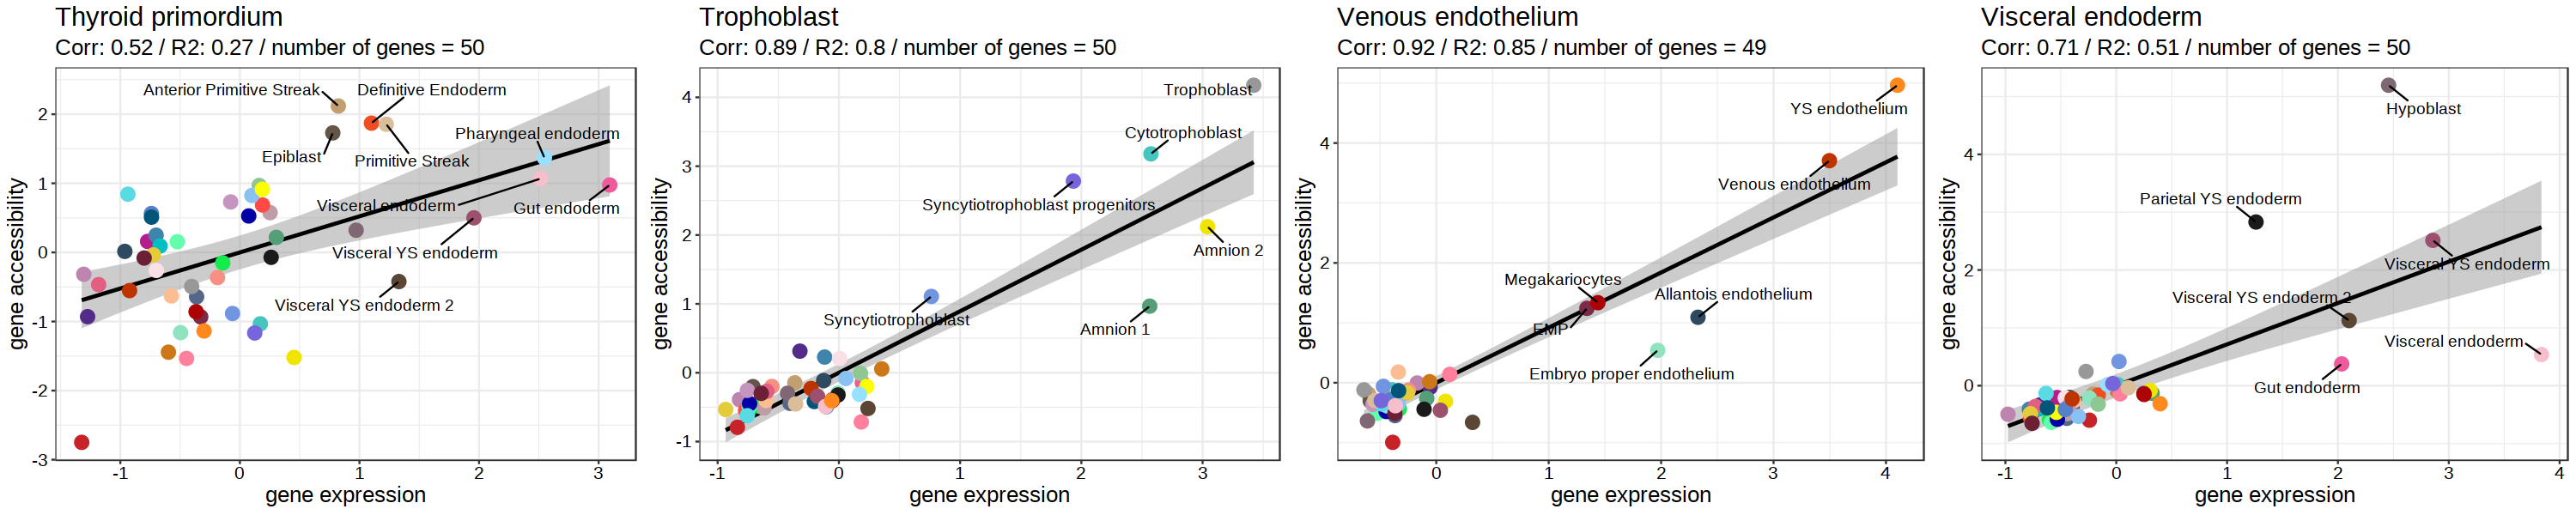

$`1`

$`2`

$`3`

$`4`

$`5`

$`6`

$`7`

$`8`

$`9`

$`10`

$`11`

$`12`

$`13`

$`14`

$`15`

$`16`

$`17`

attr(,"class")
[1] "list"      "ggarrange"

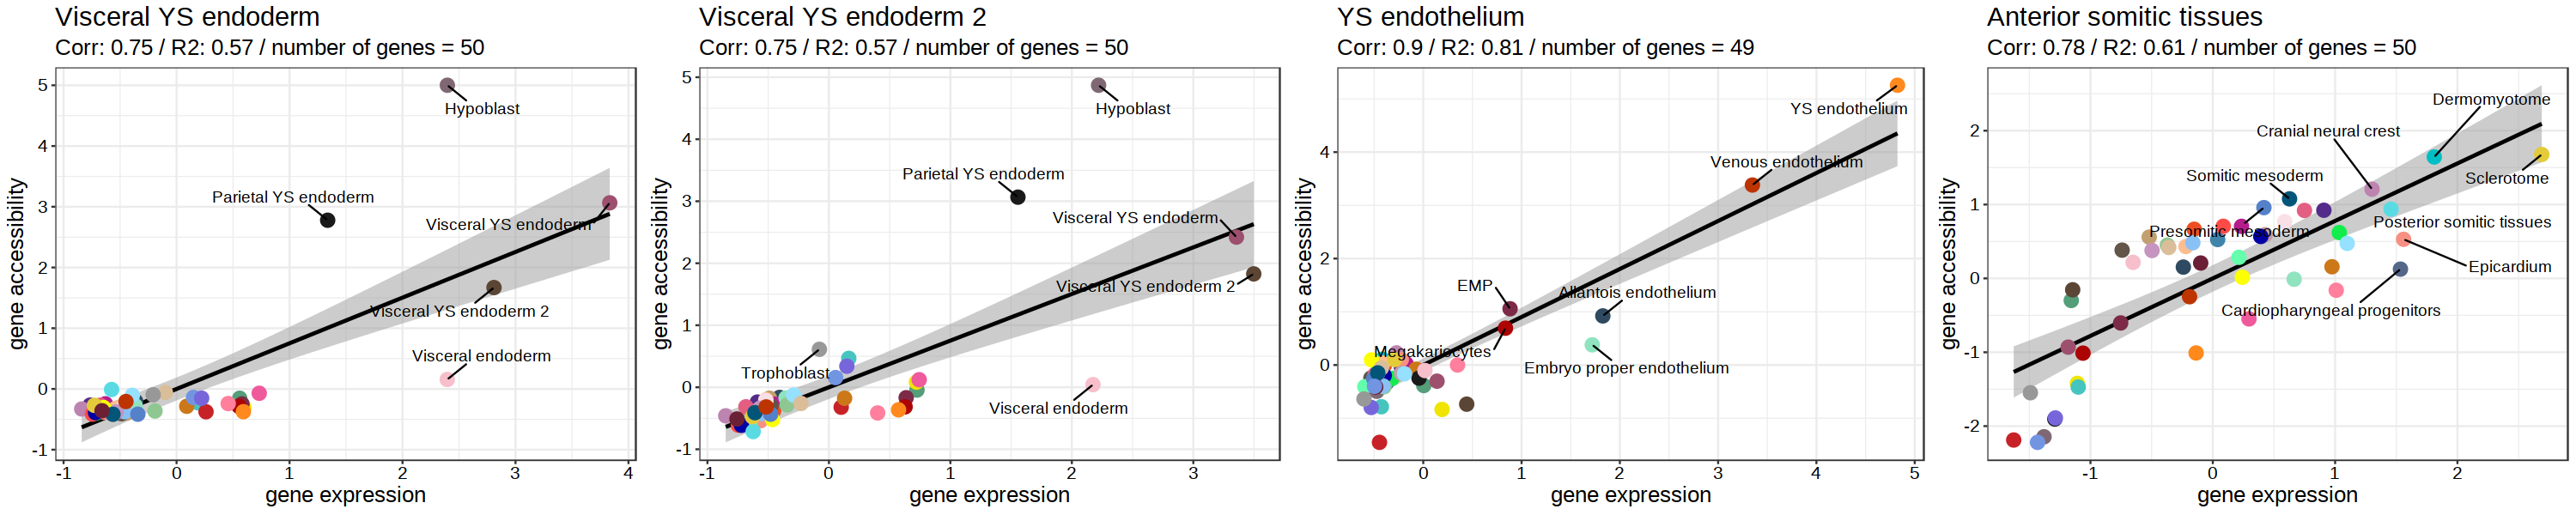

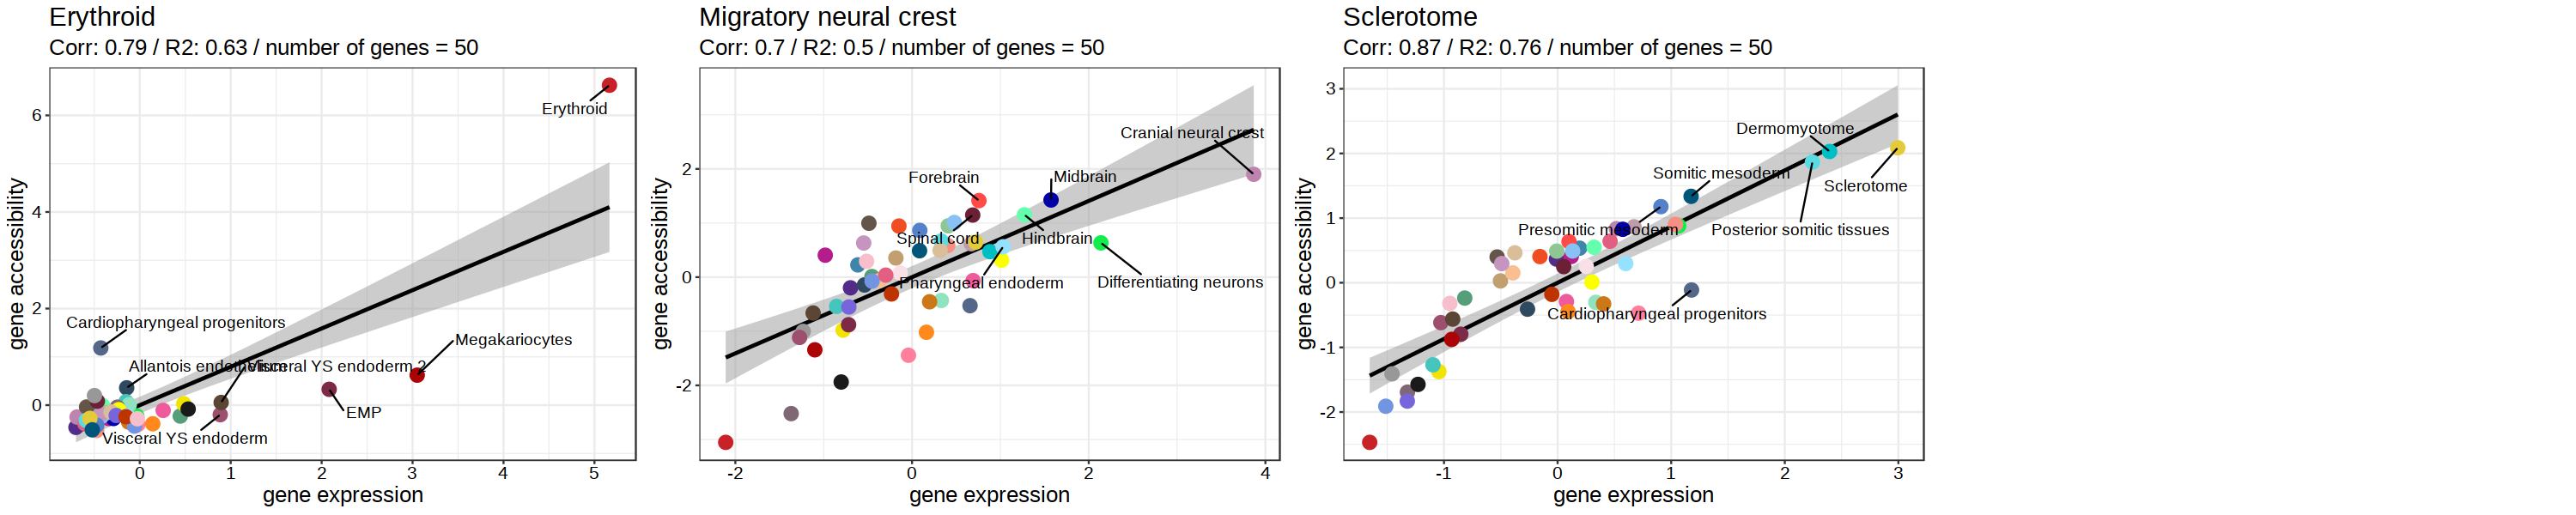

In [16]:
ggarrange(plotlist=p, ncol=4)

In [24]:
# pdf('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR/mapping/celltype_markers_top50.pdf', width=36, height=6, onefile=T)
#     # for (i in seq(length(p))) {
#     #   do.call("grid.arrange", p[[i]])  
#     # }
#     ggarrange(plotlist=p, ncol=6)
# dev.off()

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using for

$`1`

$`2`

$`3`

$`4`

$`5`

$`6`

$`7`

$`8`

$`9`

$`10`

$`11`

$`12`

attr(,"class")
[1] "list"      "ggarrange"

png 
  2

## Per germ layer

In [17]:
options(repr.plot.width=6, repr.plot.height=6)


In [18]:
celltype_correlation = function(x, logFC_i=0, head_i=50, scale=TRUE){
        markers_tmp = RNA_all_markers[celltype==x] %>% 
            .[logFC>logFC_i] %>% 
            .[order(-logFC), gene] %>% head(head_i)
        markers_tmp = intersect(markers_tmp, rownames(atac.mtx))

        if(length(markers_tmp)>1){
            rna.tmp = data.table(celltype = colnames(rna.mtx), rna_counts = colMeans(rna.mtx[markers_tmp,]))
            atac.tmp =  data.table(celltype = colnames(atac.mtx), atac_counts = colMeans(atac.mtx[markers_tmp,]))
            
            # Combine RNA & ATAC in one dt
            merge = merge(rna.tmp, atac.tmp, by='celltype') %>%
                .[,num_genes:= length(markers_tmp)] %>% # add gene number info
                .[,corr:=round(cor(rna_counts, atac_counts, method='pearson'),2)] # Add Correlation info
            
            # Scale
            if(scale==TRUE){
                merge = merge %>%
                .[,`:=`(rna_counts = scale(rna_counts),
                        atac_counts = scale(atac_counts))]
            }

            # Add lm info
            lm = lm(rna_counts ~ atac_counts, merge)

            merge = merge %>% 
                .[,`:=`(R2 = round(summary(lm)$r.squared,2),
                        slope = lm$coefficients[2],
                        intercept = lm$coefficients[1], 
                        celltype_markers = x)]
                        
            return(merge)
    }
}

plot_celltype_correlation = function(celltype_list, logFC_i=1, head_i=50, scale=TRUE, title=NULL, text_size=5){
    
    tmp = lapply(celltype_list, celltype_correlation, logFC_i = logFC_i, head_i = head_i, scale = scale) %>% rbindlist()
    
    # rename megakaryocytes
    tmp = tmp %>% .[,celltype_markers:=ifelse(celltype_markers=='Megakariocytes', 'Megakaryocytes', celltype_markers)]
    
    p = ggplot(tmp, aes(rna_counts, atac_counts, col=celltype_markers)) + 
                geom_vline(xintercept=0, color = 'grey75',linetype = "longdash") + 
                geom_hline(yintercept=0, color = 'grey75',linetype = "longdash") + 
                geom_abline(slope=1, color='red', linetype = "longdash", size=0.5) + 
                geom_smooth(method='lm', se=FALSE) + 
                scale_colour_manual(values=opts$celltype_colours) +  
                xlab('Scaled Marker Gene Expression (RNA)') + ylab('Scaled Marker Gene Activity (ATAC)') + 
                ggtitle(title) +
               # xlim(min(tmp$atac_counts), (max_line$intercept + max_line$slope * max_line$rna_counts)) + 
                theme_bw() +
                theme(legend.position='none',
                      text=element_text(size=18, color='black'),
                      axis.text=element_text(color='black'),
                      panel.grid = element_blank(),
                     panel.border = element_rect(fill=NA, color='black'))
    
    # Add text labels
    plot_height = layer_scales(p)$y$range$range[2] # get plot height
    x_dist = max(tmp$rna_counts) - min(tmp$rna_counts) # get x dist
    y_dist = plot_height - min(tmp$atac_counts) # get y dist
    n = length(unique(tmp$celltype_markers))
    label.dt = tmp %>% unique(by='celltype_markers') # get celltype & R2
    labels = data.table(rna_counts =  rep(min(tmp$rna_counts)-0.05*x_dist, n), # dist from min(x)
                       atac_counts =  (plot_height - text_size/100*y_dist*0:(n-1)), # every celltype on a new row
                       celltype_markers = label.dt$celltype_markers,
                       label = paste0(label.dt$celltype_markers, ' (R2:', label.dt$R2, ')')) # add celltype and R2
    
    # Add to plot 
    p = p + geom_text(data=labels, aes(rna_counts, atac_counts, col=celltype_markers, label=label), size=text_size, hjust=0)
    

       
    return(p)
}

In [24]:
epiblast = c('Epiblast',
            'Primitive Streak',
            'Anterior Primitive Streak')
test = lapply(epiblast, celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()

In [ ]:
tmp = test

In [ ]:
head(tmp)

celltype,rna_counts,atac_counts,num_genes,corr,R2,slope,intercept,celltype_markers
<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Allantois,-0.9037897,-0.18643992,50,0.85,0.72,0.8488282,-3.953162e-16,Epiblast
Allantois endothelium,-0.7348205,-0.14937315,50,0.85,0.72,0.8488282,-3.953162e-16,Epiblast
Amnion 1,-1.2432189,-0.06021786,50,0.85,0.72,0.8488282,-3.953162e-16,Epiblast
Amnion 2,-1.1249970,-1.90334238,50,0.85,0.72,0.8488282,-3.953162e-16,Epiblast
Anterior Primitive Streak,1.3362514,0.97430914,50,0.85,0.72,0.8488282,-3.953162e-16,Epiblast
Cardiomyocytes FHF 2,-0.3001905,0.29632424,50,0.85,0.72,0.8488282,-3.953162e-16,Epiblast


In [50]:
# Data export for NCB

epiblast = c('Epiblast',
            'Primitive Streak',
            'Anterior Primitive Streak')
p1 = lapply(epiblast, celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()

tropho = c('Trophoblast', 'Cytotrophoblast', 'Syncytiotrophoblast progenitors', 'Syncytiotrophoblast')
p2 = lapply(tropho, celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()

hypo = c('Visceral endoderm', 'Parietal YS endoderm','Visceral YS endoderm','Visceral YS endoderm 2', 'Definitive Endoderm', 'Gut endoderm', 'Hypoblast')
p3 = lapply(hypo, celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()

amnion = c('Non-neural ectoderm 2', 'Amnion 1','Amnion 2', 'Amnion 3')
p4 = lapply(amnion, celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()

blood_endothelium = c('Haematoendothelial progenitors',
                'Embryo proper endothelium',
                'Allantois endothelium',
                'Venous endothelium',
                'YS endothelium',
                'Megakariocytes', 
                'Erythroid',
                'EMP'
)
p5 = lapply(blood_endothelium, celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()

other_mesoderm = c('Cardiopharyngeal progenitors',
                   'NMPs/Mesoderm-biased', 
                    'Posterior somitic tissues',  
                    'Lateral plate mesoderm',  
                    'Cardiomyocytes FHF 2', 
                    'Presomitic mesoderm',
                    'Somitic mesoderm',
                    'Nascent mesoderm',
                    'Caudal mesoderm',
                    'Limb mesoderm',
                    'Dermomyotome',
                    'Mesothelium',
                    'Mesenchyme',
                    'Epicardium',
                    'Sclerotome',
                    'Allantois'
)

p6 = lapply(other_mesoderm, celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()

ectoderm = c('Differentiating neurons',
            'Cranial neural crest',
            'Floor plate',
            'Spinal cord',
            'Forebrain', 
            'Midbrain', 
            'Hindbrain',
            'NMPs')
p7 = lapply(ectoderm, celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()

p0 = lapply('Syncytiotrophoblast', celltype_correlation, logFC_i = 1, head_i = 50, scale = TRUE) %>% rbindlist()


In [53]:
plot_data = rbind(p0, p1,p2,p3,p4,p5,p6,p7)
fwrite(plot_data, '/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/Figures_data_NCB/S6E_RNA_ATAC_Correlation.csv')

In [44]:
options(repr.plot.width=6, repr.plot.height=6)

epiblast = c('Epiblast',
            'Primitive Streak',
            'Anterior Primitive Streak')
p1 = plot_celltype_correlation(epiblast, scale=TRUE, title='Epiblast - Primitive Streak', text_size=5)

tropho = c('Trophoblast', 'Cytotrophoblast', 'Syncytiotrophoblast progenitors', 'Syncytiotrophoblast')
p2 = plot_celltype_correlation(tropho, scale=TRUE, title='Trophoblast', text_size=5)

hypo = c('Visceral endoderm', 'Parietal YS endoderm','Visceral YS endoderm','Visceral YS endoderm 2', 'Definitive Endoderm', 'Gut endoderm', 'Hypoblast')
p3 = plot_celltype_correlation(hypo, scale=TRUE, title='Endoderm', text_size=5)

amnion = c('Non-neural ectoderm 2', 'Amnion 1','Amnion 2', 'Amnion 3')
p4 = plot_celltype_correlation(amnion, scale=TRUE, title='Amnion', text_size=5.5)

blood_endothelium = c('Haematoendothelial progenitors',
                'Embryo proper endothelium',
                'Allantois endothelium',
                'Venous endothelium',
                'YS endothelium',
                'Megakariocytes', 
                'Erythroid',
                'EMP'
)
p5 = plot_celltype_correlation(blood_endothelium, scale=TRUE, title='blood & endothelium', text_size=5)

other_mesoderm = c('Cardiopharyngeal progenitors',
                   'NMPs/Mesoderm-biased', 
                    'Posterior somitic tissues',  
                    'Lateral plate mesoderm',  
                    'Cardiomyocytes FHF 2', 
                    'Presomitic mesoderm',
                    'Somitic mesoderm',
                    'Nascent mesoderm',
                    'Caudal mesoderm',
                    'Limb mesoderm',
                    'Dermomyotome',
                    'Mesothelium',
                    'Mesenchyme',
                    'Epicardium',
                    'Sclerotome',
                    'Allantois'
)

p6 = plot_celltype_correlation(other_mesoderm, scale=TRUE, title='Other Mesoderm', text_size=4)

ectoderm = c('Differentiating neurons',
            'Cranial neural crest',
            'Floor plate',
            'Spinal cord',
            'Forebrain', 
            'Midbrain', 
            'Hindbrain',
            'NMPs')
p7 = plot_celltype_correlation(ectoderm, scale=TRUE, title='Ectoderm', text_size=5.5)


`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'



In [35]:
options(repr.plot.width=5, repr.plot.height=5)

SCT_plot = p2$data[celltype_markers=='Syncytiotrophoblast']
p0 = ggplot(SCT_plot, aes(rna_counts, atac_counts)) + 
                # background lines
                geom_vline(xintercept=0, color = 'grey75',linetype = "longdash") + 
                geom_hline(yintercept=0, color = 'grey75',linetype = "longdash") + 
                geom_abline(slope=1, color='red', linetype = "longdash", size=0.5) + 
                # plot data
                geom_smooth(method='lm', col=opts$celltype_colours[names(opts$celltype_colours)=='Syncytiotrophoblast'], se=F) + 
                geom_point(size=4, aes(col=celltype)) + 
                ggrepel::geom_text_repel(data=unique(rbind(head(SCT_plot[order(-rna_counts)], 5), head(SCT_plot[order(-atac_counts)], 5))), # label top 5 of atac & rna
                                         aes(label=celltype),
                                         box.padding=0.8) + 
                # titles
                ggtitle(SCT_plot$celltype_markers[1],
                       paste('Corr:', SCT_plot$corr[1], 
                             '/ R2:', SCT_plot$R2[1], 
                             '/ genes =', SCT_plot$num_genes[1])) + 
                xlab('Scaled Marker Gene Expression (RNA)') + ylab('Scaled Marker Gene Activity (ATAC)') + 
                # themes
                scale_colour_manual(values=opts$celltype_colours) + 
                theme_bw() +
                theme(legend.position='none',
                      text=element_text(size=18, color='black'),
                      axis.text=element_text(color='black'),
                      panel.grid = element_blank(),
                      panel.border = element_rect(fill=NA, color='black'),
                      plot.title = element_text(color = opts$celltype_colours[names(opts$celltype_colours)=='Syncytiotrophoblast']),
                      plot.subtitle = element_text(color = opts$celltype_colours[names(opts$celltype_colours)=='Syncytiotrophoblast']))

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'



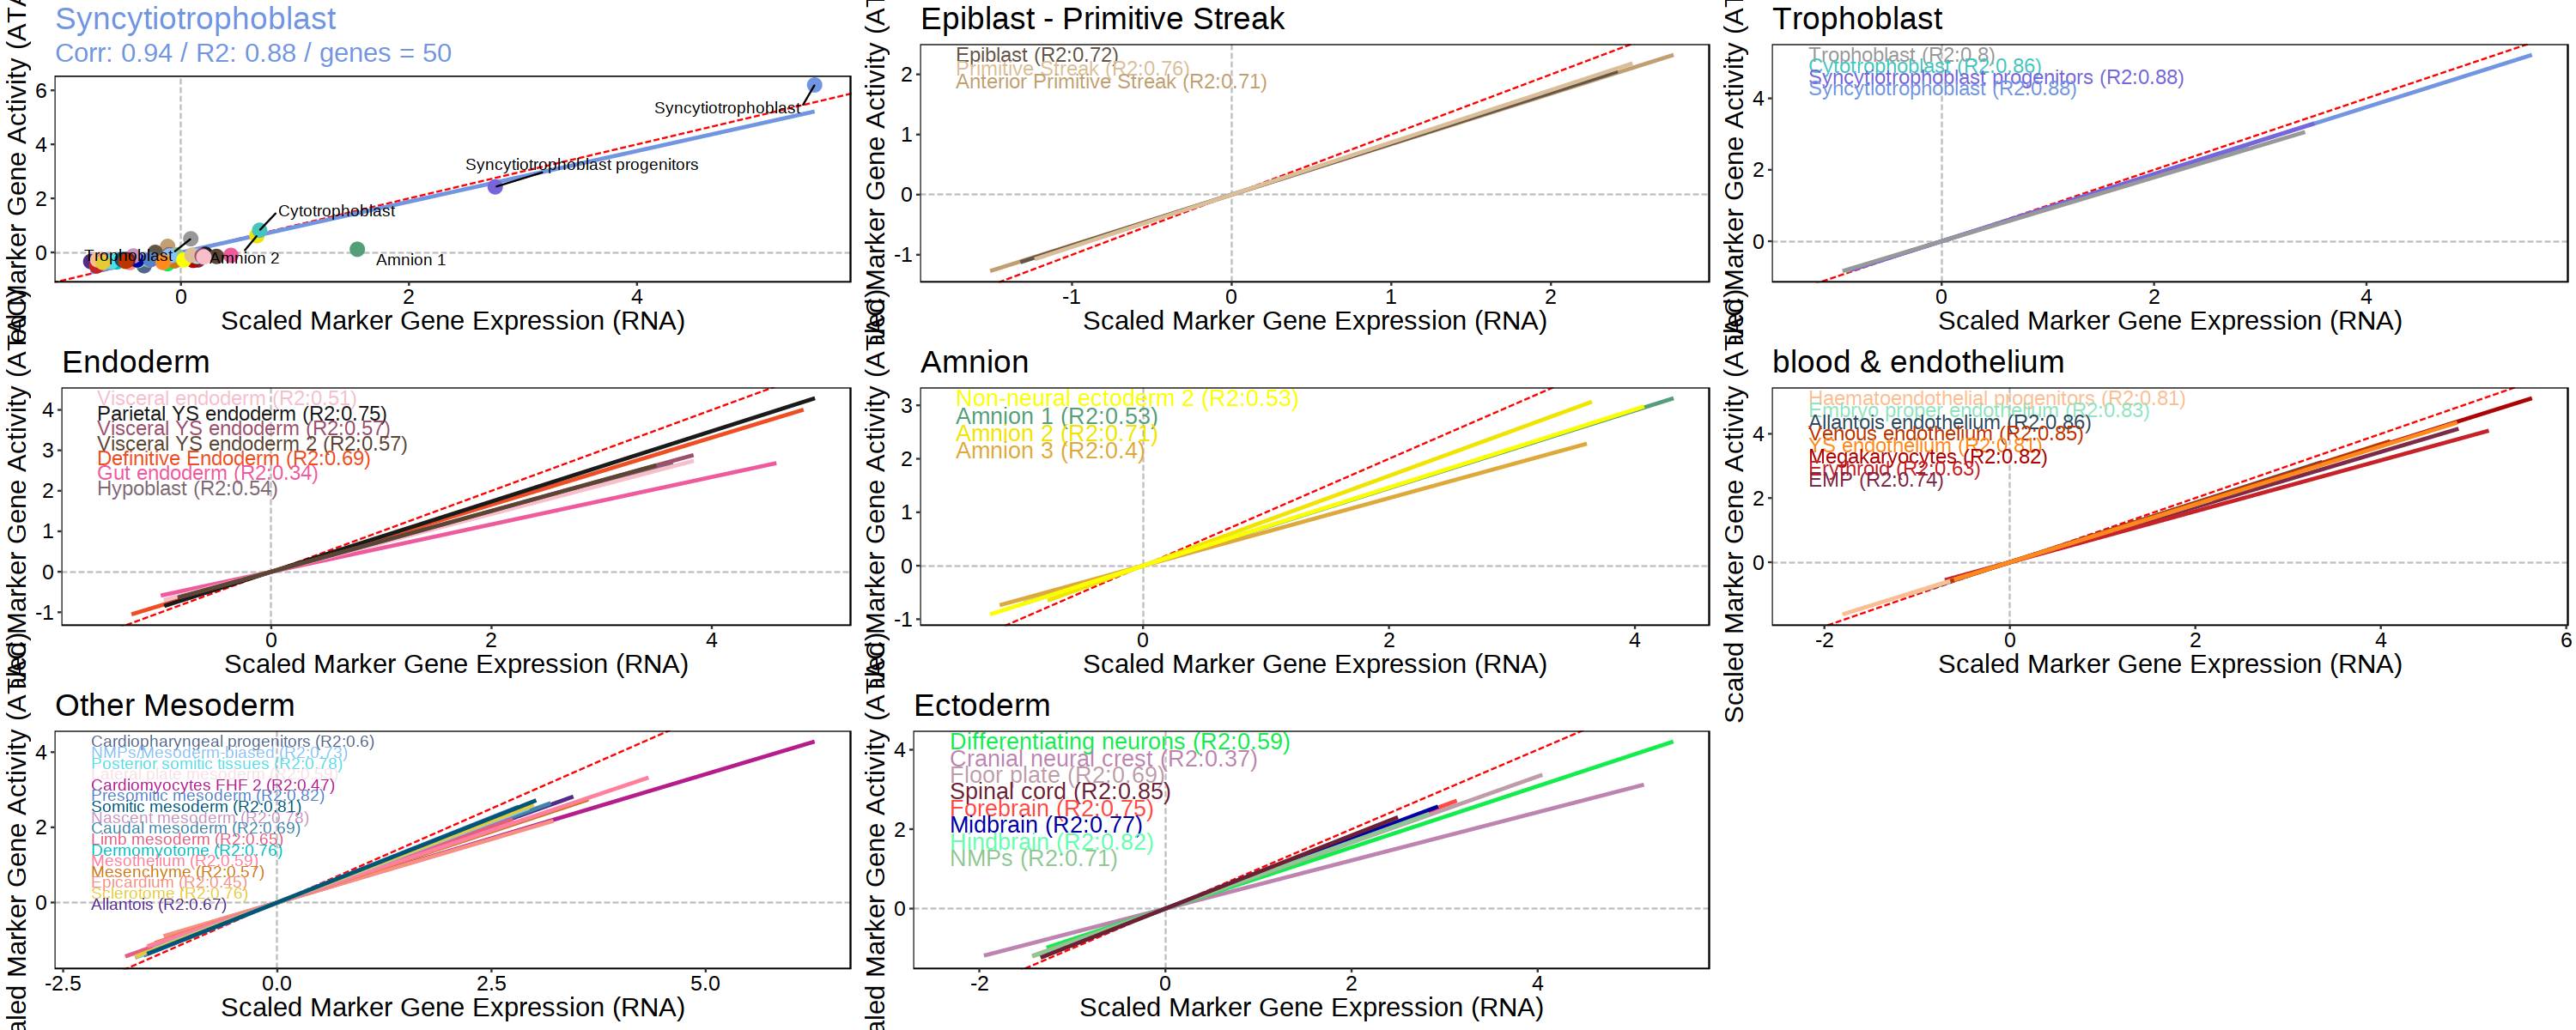

In [36]:
options(repr.plot.width=25, repr.plot.height=10)

ggarrange(p0, p1,p2,p3,p4,p5,p6,p7)

In [65]:
pdf('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR/mapping/celltype_markers_combined_top20.pdf', width=20, height=5, onefile=T)
    # for (i in seq(length(p))) {
    #   do.call("grid.arrange", p[[i]])  
    # }
    ggarrange(p0, p1,p2,p3,p4,p5,p6,p7, ncol=4)
dev.off()

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'



$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

png 
  2

# Mapping score

In [2]:
meta = as.data.table(ArchRProject@cellColData)

In [193]:
head(meta)

Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,nMonoFrags,nFrags,⋯,Clusters_TileMatrix,ReadsInPeaks,FRIP,Clusters_PeakMatrix,predictedCell_Un_PeakMatrix,predictedGroup_celltype_PeakMatrix,predictedScore_celltype_PeakMatrix,stage_clusters,cell,celltype_v1
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
rabbit_BGRGP1,3.903,2186,20885,0.10854990,1,1.0802699,18747,46244,96200,⋯,C8,72639,0.3775416,C7,cell_17967,Hypoblast,1.0000000,GD7_C10,rabbit_BGRGP1#CAAGGCCGTATACGCT-1,Hypoblast_Parietal YS endoderm
rabbit_BGRGP1,4.103,1701,17002,0.08887425,1,0.8214571,11707,52514,95652,⋯,C19,47563,0.2486252,C22,cell_8273,Haematoendothelial progenitors,0.5651694,GD7_C14,rabbit_BGRGP1#ATCCTCGTCCGAATTG-1,Epiblast
rabbit_BGRGP1,3.960,2150,20237,0.10687503,1,0.9351252,14408,48925,94676,⋯,C14,66350,0.3504056,C20,cell_6204,Nascent mesoderm,0.5654089,GD7_C15,rabbit_BGRGP1#CTTGCCATCTGAGTAC-1,Nascent mesoderm_Epiblast
rabbit_BGRGP1,3.625,1770,17631,0.09643701,1,1.1812021,11842,41909,91412,⋯,C19,51716,0.2828731,C22,cell_10802,Epiblast,0.8727447,GD7_C14,rabbit_BGRGP1#AACAGTCTCCGATGCG-1,Epiblast
rabbit_BGRGP1,3.658,1657,16336,0.08980660,1,0.9994944,12648,45487,90951,⋯,C19,48186,0.2649009,C22,cell_11468,Epiblast,0.8491864,GD7_C14,rabbit_BGRGP1#GGTGAAGTCGTCGCAG-1,Epiblast
rabbit_BGRGP1,4.029,1890,17581,0.09674455,1,0.9643506,15049,46256,90863,⋯,C14,56075,0.3085689,C20,cell_12442,Epiblast,0.8585445,GD7_C16,rabbit_BGRGP1#ATCGAGTAGAGGAATG-1,Epiblast


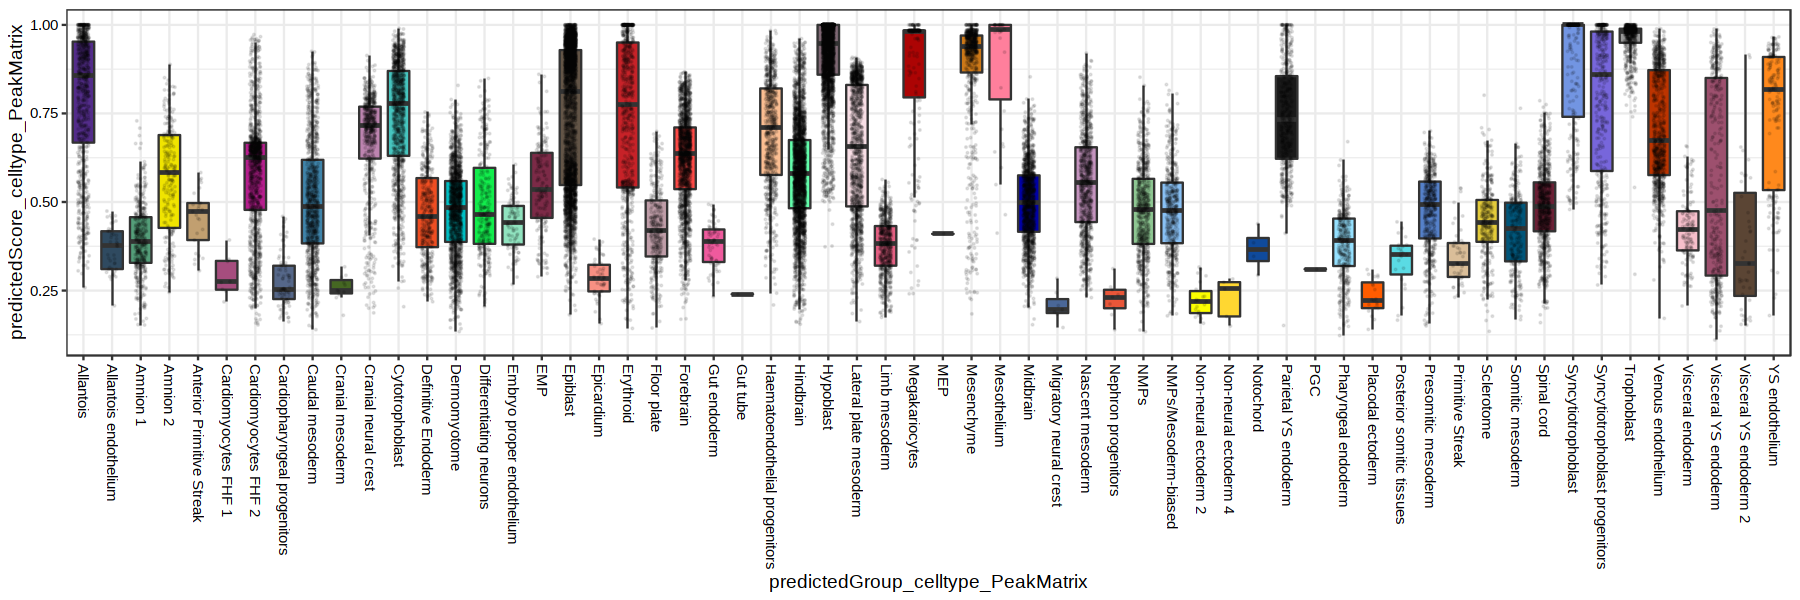

In [19]:
ggplot(meta, aes(predictedGroup_celltype_PeakMatrix, predictedScore_celltype_PeakMatrix)) + 
    geom_boxplot(outlier.shape=NA, aes(fill=predictedGroup_celltype_PeakMatrix)) + 
    geom_point(position=position_jitter(width=0.2), size=0.1, alpha=0.1) + 
    scale_fill_manual(values = opts$celltype_colours) + 
    theme_bw() +
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(color='black'),
         legend.position='none')

# Marker genes heatmap

In [103]:
minmax = function(x){
    (x - min(x))/(max(x) - min(x))
}

In [470]:
plot_genes <- list("Allantois" = c("HAND2", "WNT2"),
                   "Allantois endothelium" = c("HOXA11", "CDH5"),
                   "Amnion 1" = c("AQP2","TAC4","LGALS3"),
                   "Amnion 2" = c("VTCN1","WNT6", "LGALS3"),
                   "Amnion 3" = c("GABRP", "WNT6", "VTCN1"),
                   'Anterior cardiopharyngeal progenitors' = c("ISL1","TCF21", "VCAN", "SIX1"  ),
                   'Anterior Primitive Streak' = c("EOMES",'POU5F1', "EPCAM"),
                   'Anterior somitic tissues' = c("TCF15","MARCKS","PAX1", "PRRX2"),
                   'Cardiomyocytes FHF 1' = c("TBX5", "WNT2","MYL4",'NKX2-5'),
                   'Cardiomyocytes FHF 2' = c('NKX2-5','MYL9','MYL3'),
                   'Cardiopharyngeal progenitors' = c("WNT2", "NR2F2"),
                   'Caudal mesoderm' = c('HOXA9','CDX4','HOXC6'),
                   'Cranial mesoderm' = c('COLEC12','SIX1','MYL9'),
                   'Cranial neural crest' = c('COL2A1',"TFAP2A"),
                   'Cytotrophoblast' = c('CYP19A1','SLC13A4'),
                   'Definitive Endoderm' = c('FOXA2',"EPCAM", "POU5F1"),
                   'Dermomyotome' = c('DMRT2','PAX3','MEOX2','CADM1','DMRT2','ALDH1A2','MYF5','MEOX1'),
                   'Differentiating neurons' = c('ELAVL4','NEUROD4','SOX4_HUMAN',"PAX3"),
                   'Early SCT' = c('GATA3','KLF6','DAB2','SHCBP1',"TFAP2A"),
                   'Embryo proper endothelium' = c('KDR','CDH5','IGFBP4'),
                   'EMP' = c('RUNX1', 'INKA1','MEF2C'),
                   'Endocardium' = c('PECAM1','VWF'),
                   'Epiblast' = c('POU5F1', "EPCAM"),
                   'Epicardium' = c('TCF21','PEG3','TPM1'),
                   'Erythroid' = c('TAL1','GATA1'),
                   'Floor plate' = c('SHH','FOXA2'),
                   'Forebrain' = c('OTX2','PAX6','LHX2'),
                   'Gut endoderm' = c('FN1','APOA2','FOXA2'),
                   'Gut tube' = c('PLAT','DKK1','FOXA2'),
                   'Haematoendothelial progenitors' = c('INKA1','EBNA1BP2','WDR12','TOMM20'),
                   'Hindbrain' = c('GBX2','HOXA2','HOXD3'),
                   'Hypoblast' = c('APOA1','TFPI','APOB', 'FOXA2'),
                   'Lateral plate mesoderm' = c('BMP4','CDX4','CDX2','HOXB6'),
                   'Limb mesoderm' = c('PRRX1','TBX5','HAND2'),
                   'Megakariocytes' = c('PLEK','ITGA2B'),
                   'MEP' = c('GATA1', 'ALAS2','HBZ','TAL1'),
                   'Mesenchyme' = c('COL3A1','ITGA4','DLK1','LGALS1'),
                   'Mesothelium' = c('LUM','COLEC10','ADAMTS9'),
                   'Mesothelium-endothelium/Masked' = c('VIM','ITM2B','RAMP2','LUM'),
                   'Midbrain' = c('PAX6','SFRP2'),
                   'Migratory neural crest' = c('TFAP2B','SOX9','PAX3'),
                   'Nascent mesoderm' = c('TBXT','EOMES','MIXL1'),
                   'Nephron progenitors' = c('PAX2','NRP1'),
                   'NMPs' = c('CDX4','TBXT','CDX2','CDX1','RSPO3'),
                   'NMPs/Mesoderm-biased' = c('CDX2','CDX4','RSPO3','CDX1','CYP26A1'),
                   'Non-neural ectoderm 2' = c('WNT6', 'TFAP2A'),
                   'Non-neural ectoderm 4' = c('TFAP2A','WNT6','CLDN6'),
                   'Notochord' = c('NOTO', 'CHRD','SHH','FOXA2'),
                   'Parietal YS endoderm' = c('DKK1','LAMA1','COL4A2','FABP3' ),
                   'PGC' = c('NANOS3','KIT','POU5F1'),
                   'Pharyngeal endoderm' = c('CLDN6','SIX1','RAB25','IGFBP5'),
                   'Placodal ectoderm' = c('SIX1','OTX2','CLDN6'),
                   'Posterior somitic tissues' = c('DLL3','CADM1','TCF15','FST','GPC3'),
                   'Presomitic mesoderm' = c('TBX6', 'MSGN1','TBXT'),
                   'Primitive Streak' = c('EPCAM','POU5F1','PSIP1','EOMES','RAB25'),
                   'Roof plate' = c('MSX2','MSX1_HUMAN','RSPO3','CRABP2'),
                   'Sclerotome' = c('ALDH1A2','MEOX1','TCF15'),
                   'SCT progenitors' = c('GCM1', 'CEBPA','TFAP2C'),
                   'Somitic mesoderm' = c('EPHA4','HOXB9','TBX6'),
                   'Spinal cord' = c('HOXB9','GBX2','PAX6','HOXA7'),
                   'Thyroid primordium' = c('GPC3','CLDN6','EPCAM','IGFBP5', 'FOXA2'),
                   'Trophoblast' = c('HAND1','WNT6','CALM2','EPCAM'),
                   'Venous endothelium' = c('RAMP2','CDH5','GNG11','TFPI'),
                   'Visceral endoderm' = c('SLC16A1','FABP3','APOA1','EPCAM'),
                   'Visceral YS endoderm' = c('APOM','APOA4','TTR','AFP'),
                   'Visceral YS endoderm 2' = c('CITED1','DAB2','TTR'),
                   'YS endothelium' = c('CDH5','LGALS1','TFPI') 
                  )

In [471]:
# Extract first marker for each cell type
plot_genes <- lapply(names(plot_genes), function(x){
    first = plot_genes[[x]][1]
    names(first) = x
    return(first)
}) %>% unlist()

In [472]:
# Total genes
length(unique(unlist(plot_genes)))
# Genes also in ATAC
length(unique(unlist(plot_genes))[unique(unlist(plot_genes))%in% rownames(atac.mtx)])

[1] 67

[1] 58

In [473]:
genes_present = unique(unlist(plot_genes))[unique(unlist(plot_genes))%in% rownames(atac.mtx)]

In [474]:
meta = as.data.table(ArchRProject@cellColData)
cell_nr = as.data.table(meta) %>% .[,N:=.N, by='predictedGroup_celltype_PeakMatrix'] %>% unique(by='predictedGroup_celltype_PeakMatrix') %>% .[,c('predictedGroup_celltype_PeakMatrix', 'N')]
ct_keep = cell_nr[N>20, predictedGroup_celltype_PeakMatrix]
atac.mtx = atac.mtx[,ct_keep]

In [475]:
counts = atac.mtx

In [476]:
counts_markers = counts[genes_present,]

In [477]:
do.lognorm = F
do.percentile = T
perc_value = 0.02
do.minmax = T
do.scale = F

In [478]:
summary(counts_markers['HAND1',])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7867  1.2239  1.6211  1.9184  2.2889  4.2790 

In [479]:
summary(counts_markers['FOXA2',])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3859  0.8426  1.0355  1.2202  1.4735  3.0641 

In [480]:
transform = function(do.lognorm = F, 
                     do.percentile = T, 
                     perc_value = 0.02, 
                     do.minmax = T,
                     do.scale = F){
    counts.mod = counts_markers
    rowMins(counts.mod)[1]

    if(do.lognorm==TRUE){
        counts.mod = log2(counts.mod+1)
    }

    if(do.percentile==TRUE){
        counts.mod = mclapply(1:dim(counts_markers)[1], function(i){
            x = counts.mod[i,]
            x[x>quantile(x, 1-perc_value)] = quantile(x, 1-perc_value)
            x[x<quantile(x, perc_value)] = quantile(x, perc_value)
            return(x)
        }, mc.cores=16) %>% do.call('cbind', .) %>% t()
    }
    rowMins(counts.mod)[1]

    if(do.minmax==TRUE){
        counts.mod = apply(counts.mod, 1, minmax) %>% t()
    }
    rowMins(counts.mod)[1]

    if(do.scale==TRUE){
        counts.mod = scale(t(counts.mod)) %>% t()
    } 
    rowVars(counts.mod)[1]


    #counts.mod = t(counts.mod)

    colnames(counts.mod) = colnames(counts_markers)
    rownames(counts.mod) = rownames(counts_markers)
    return(counts.mod)
}

In [481]:
counts.mod = transform(do.lognorm = F,  # keep F
                     do.percentile = F, 
                     perc_value = 0.02, 
                     do.minmax = T, # keep T because some genes are much higher in some cell types
                     do.scale = F) # keep F

In [482]:
colnames(counts.mod)[order(colnames(counts.mod))]

[1] "Allantois"                       "Allantois endothelium"          
 [3] "Amnion 1"                        "Amnion 2"                       
 [5] "Anterior Primitive Streak"       "Cardiomyocytes FHF 2"           
 [7] "Cardiopharyngeal progenitors"    "Caudal mesoderm"                
 [9] "Cranial neural crest"            "Cytotrophoblast"                
[11] "Definitive Endoderm"             "Dermomyotome"                   
[13] "Differentiating neurons"         "Embryo proper endothelium"      
[15] "EMP"                             "Epiblast"                       
[17] "Epicardium"                      "Erythroid"                      
[19] "Floor plate"                     "Forebrain"                      
[21] "Gut endoderm"                    "Haematoendothelial progenitors" 
[23] "Hindbrain"                       "Hypoblast"                      
[25] "Lateral plate mesoderm"          "Limb mesoderm"                  
[27] "Megakariocytes"                  "Mesenchyme"                     
[29] "Mesothelium"                     "Midbrain"                       
[31] "Nascent mesoderm"                "NMPs"                           
[33] "NMPs/Mesoderm-biased"            "Non-neural ectoderm 2"          
[35] "Parietal YS endoderm"            "Pharyngeal endoderm"            
[37] "Posterior somitic tissues"       "Presomitic mesoderm"            
[39] "Primitive Streak"                "Sclerotome"                     
[41] "Somitic mesoderm"                "Spinal cord"                    
[43] "Syncytiotrophoblast"             "Syncytiotrophoblast progenitors"
[45] "Trophoblast"                     "Venous endothelium"             
[47] "Visceral endoderm"               "Visceral YS endoderm"           
[49] "Visceral YS endoderm 2"          "YS endothelium"

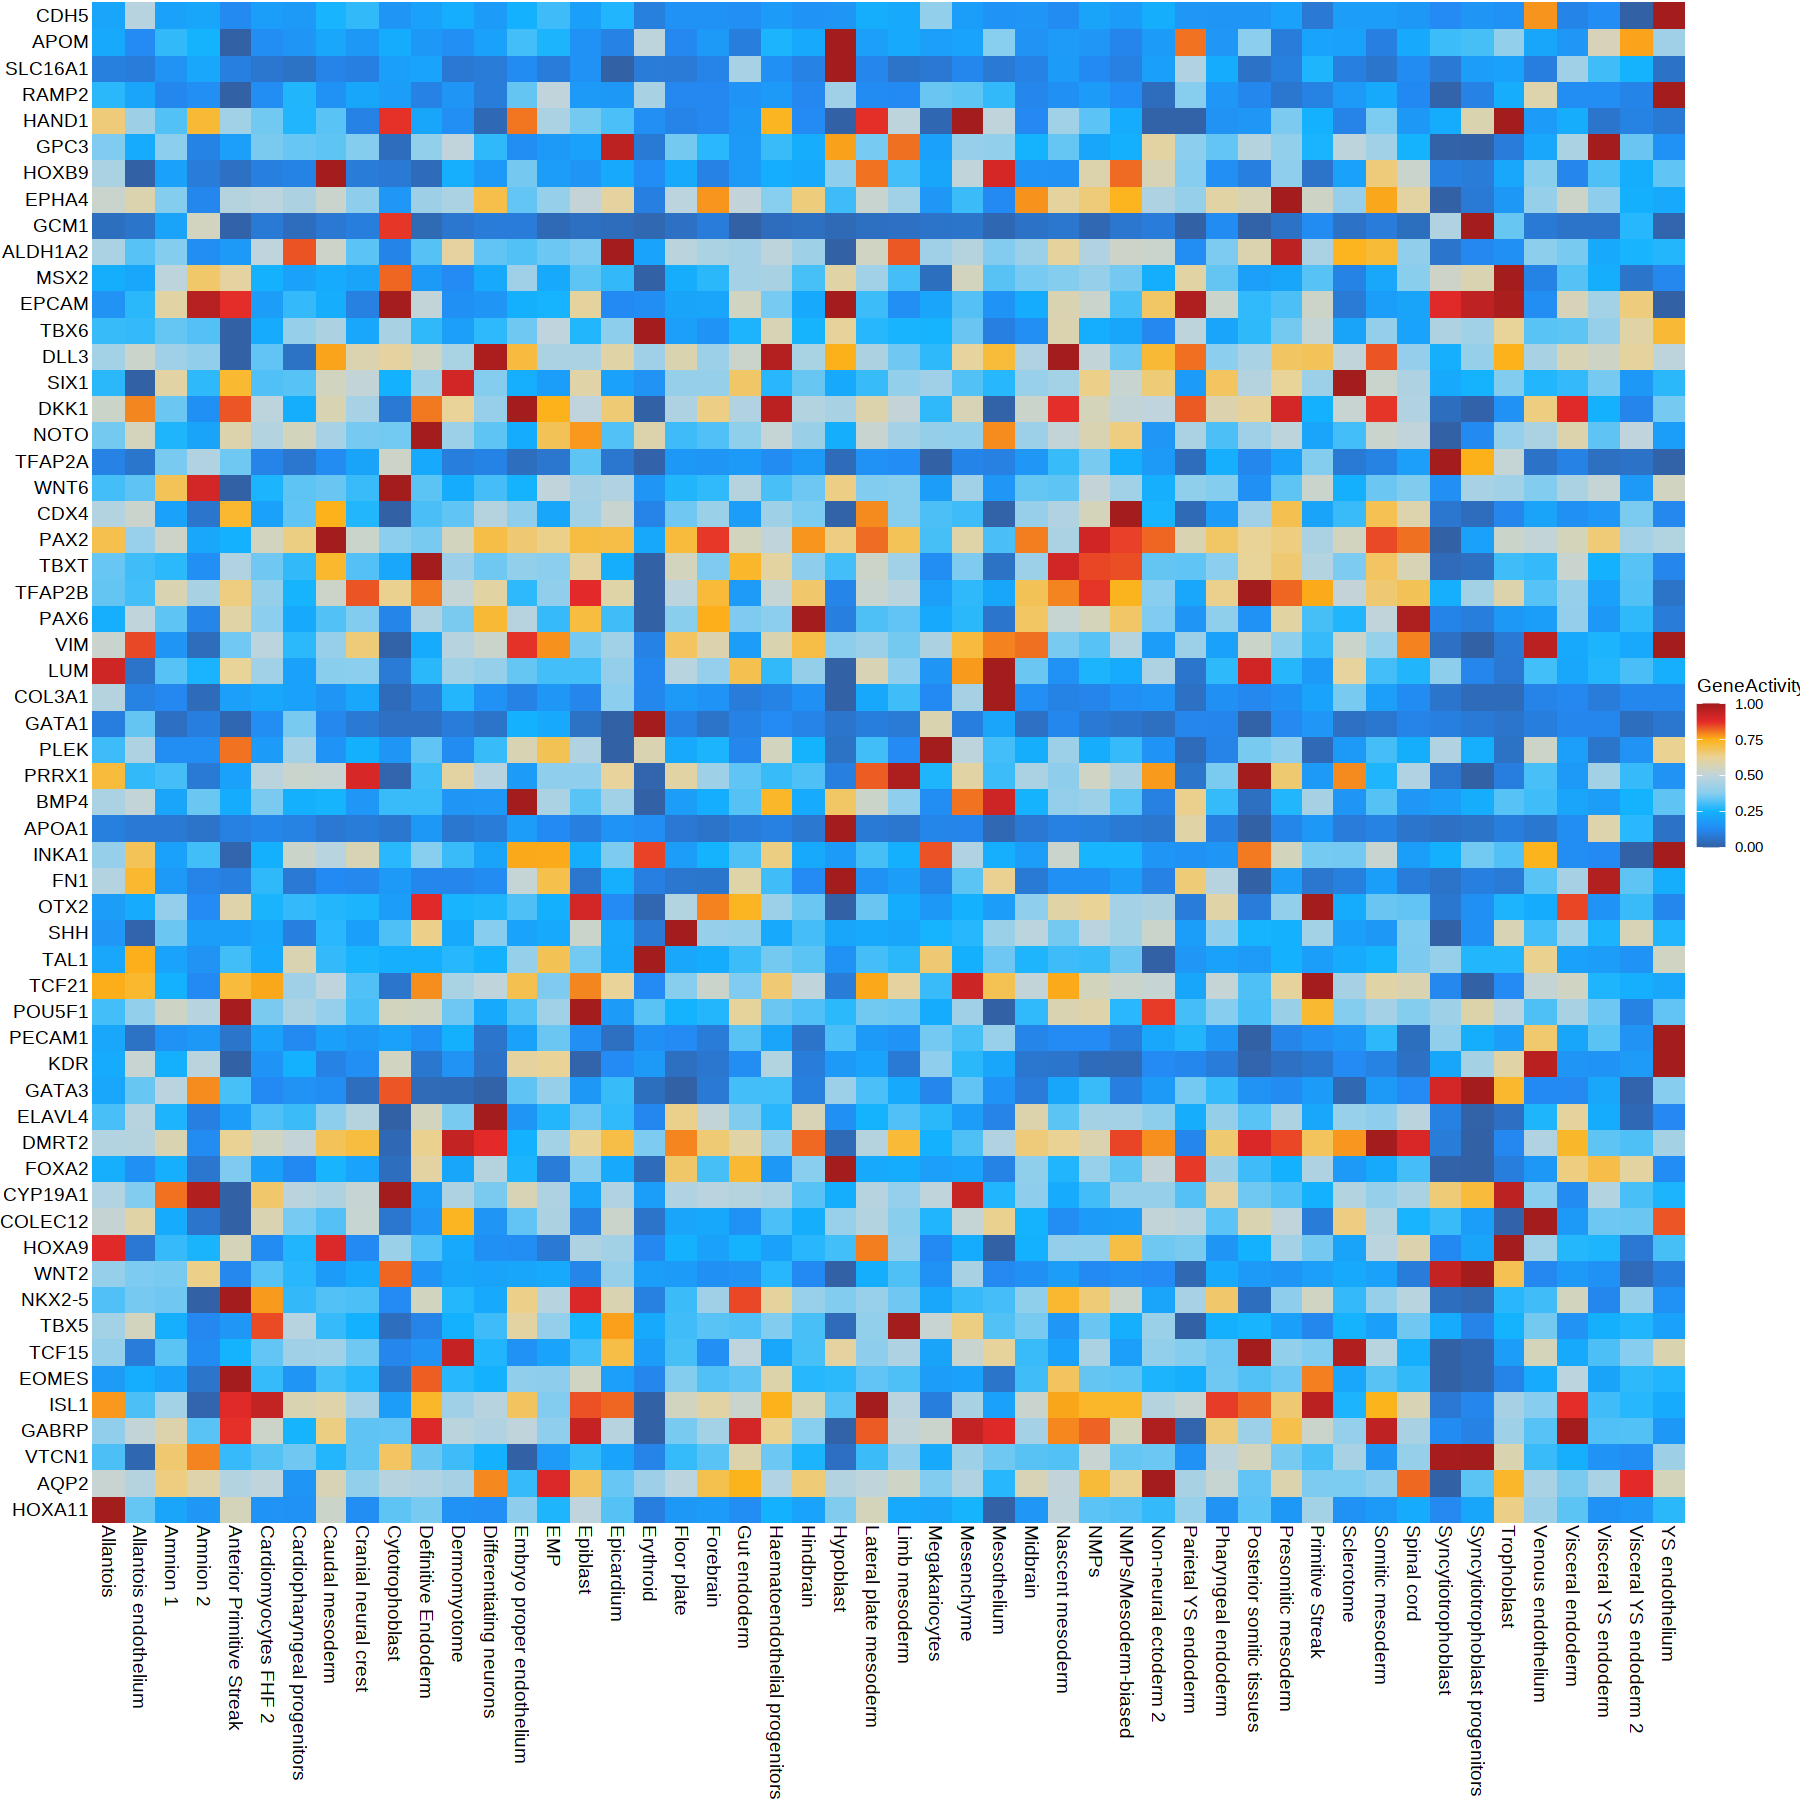

In [483]:
test = as.data.table(counts.mod, keep.rownames=T) %>%
                        setnames('rn', 'gene') %>%
                        melt(id.vars = 'gene', variable.name='celltype', value.name='GeneAccessibility') %>%
                        .[,capped:=ifelse(GeneAccessibility<=-2, -2, 
                                          ifelse(GeneAccessibility>=2, 2, GeneAccessibility))] %>%
                       .[,`:=`(gene = factor(gene, levels = unique(unlist(plot_genes))),
                               celltype = factor(celltype, levels = colnames(counts.mod)[order(colnames(counts.mod))]))]

options(repr.plot.width=15, repr.plot.height=15)
ggplot(test, aes(celltype, gene, fill=GeneAccessibility)) + 
    geom_tile() + 
    #scale_fill_gradient2(low='blue', high='red') + 
    scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity') + 
    theme_void() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text.y=element_text( hjust=1, vjust=0.5))

In [403]:
# load markers
all.markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/celltype_markers.txt.gz')

top_markers = unique(setDT(all.markers)[,head(.SD, 15), by='celltype']%>%
    .[celltype %in% ct_keep] %>%
     .[,gene])
top_markers = top_markers[top_markers %in% rownames(counts_pseudobulk)] 

In [431]:
counts_pseudobulk = gene_counts_pseudobulk@assays@data$counts
counts_pseudobulk = counts_pseudobulk[,ct_keep]
rownames(counts_pseudobulk) = rowData(gene_counts_pseudobulk)$name

In [433]:
# mean per celltype's marker
mean_markers = function(x, logFC_i=0, head_i=80, scale=TRUE){
        markers_tmp = all.markers[celltype==x] %>% 
            .[logFC>logFC_i] %>% 
            .[order(-logFC), gene] %>% head(head_i)
        markers_tmp = intersect(markers_tmp, rownames(counts_pseudobulk))

        if(length(markers_tmp)>1){
            atac.tmp =  data.table(celltype = colnames(counts_pseudobulk), celltype_markers = x, atac_counts = minmax(colMeans(counts_pseudobulk[markers_tmp,])))
            return(atac.tmp)
        } 
        # else{
        #     atac.tmp =  data.table(celltype = colnames(counts_pseudobulk), celltype_markers = x, atac_counts = minmax(counts_pseudobulk[markers_tmp,]))
        # }
    
}

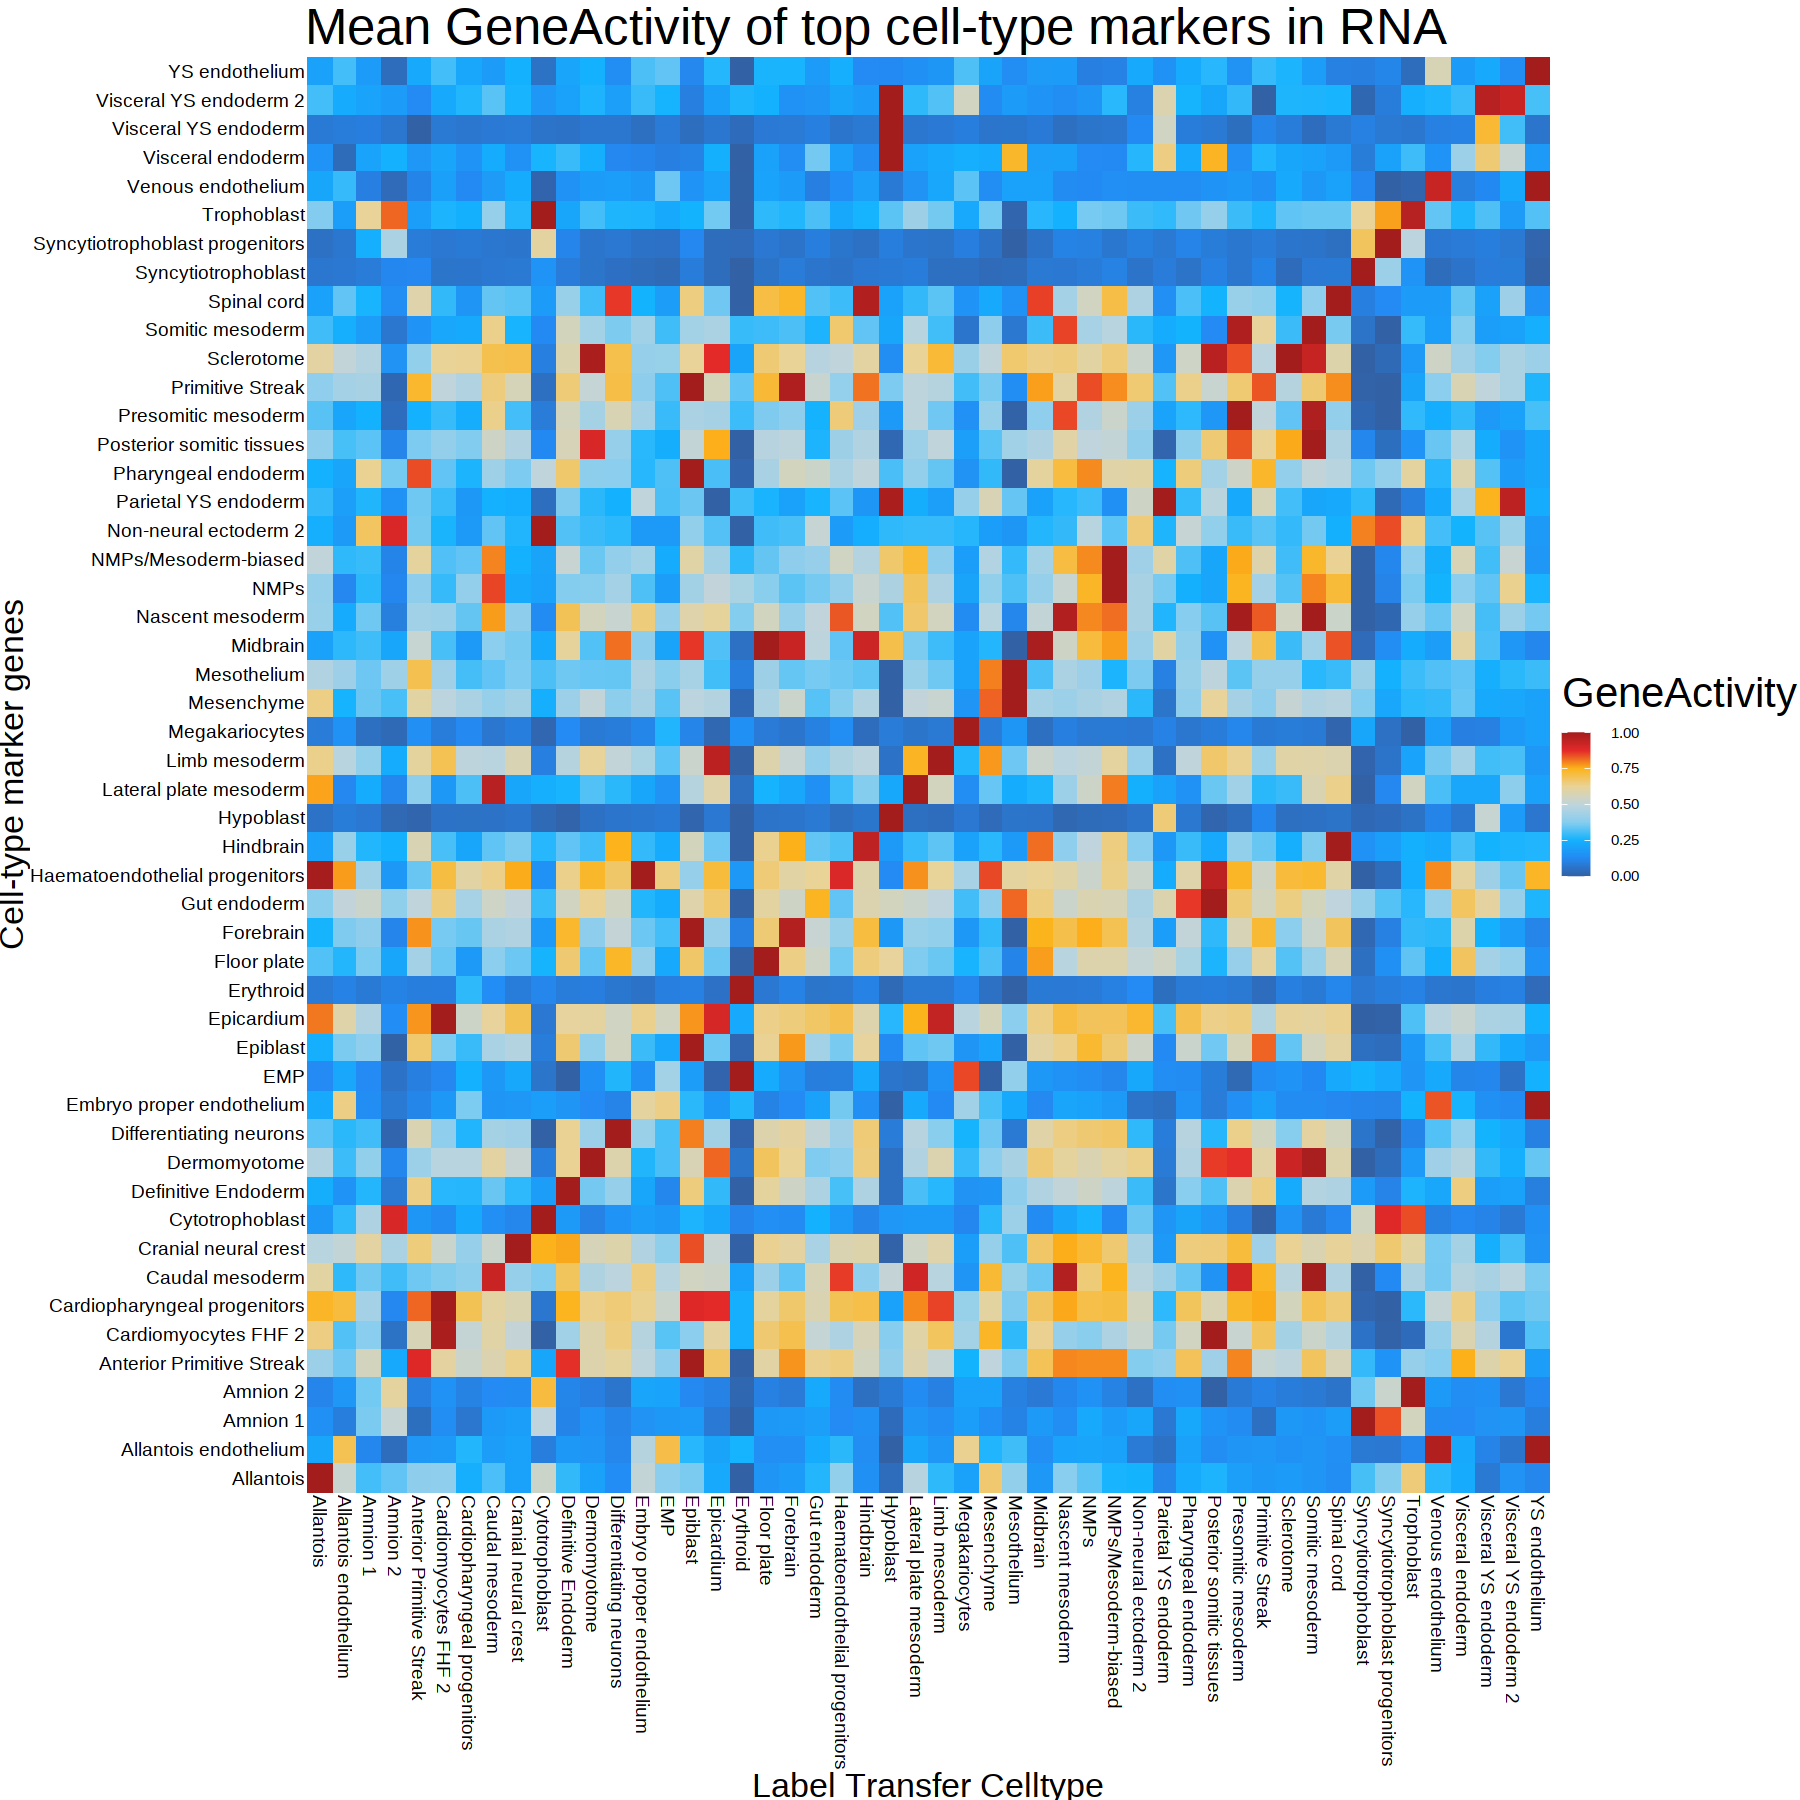

In [484]:
tmp = lapply(ct_keep, mean_markers, logFC_i = 2, head_i = 10, scale = TRUE) %>% rbindlist()

ggplot(tmp, aes(celltype, celltype_markers, fill=atac_counts)) + 
    geom_tile() + 
    scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity') + 
    ggtitle('Mean GeneActivity of top cell-type markers in RNA') + 
    xlab('Label Transfer Celltype') + 
    ylab('Cell-type marker genes') + 
    theme_void() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5,color='black'),
         axis.text.y=element_text( hjust=1, vjust=0.5,color='black'),
         axis.title=element_text(size=20),
         axis.title.y=element_text(angle=90, vjust=1),
         title=element_text(size=25))

In [23]:
minmax = function(x){
    (x - min(x))/(max(x) - min(x))
}

In [24]:
RNA_all_markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/celltype_markers.txt.gz')

In [36]:
library(scuttle)
library(scran)

Loading required package: SingleCellExperiment



In [37]:
gene_counts = readRDS(sprintf('%s/GeneScoreMatrix.rds', io$archR.directory))
# aggregate mean of GeneScoreMatrix per mapped celltype
gene_counts_pseudobulk <- aggregateAcrossCells(gene_counts, id=gene_counts$predictedGroup_celltype_PeakMatrix, statistics = 'mean', BPPARAM = BPPARAM)
rownames(gene_counts_pseudobulk) = rowData(gene_counts_pseudobulk)$name

In [105]:
top_markers = RNA_all_markers[, head(.SD, 50), by='celltype']$gene
top_markers = intersect(top_markers, rownames(gene_counts_pseudobulk))

In [106]:
gene_counts_markers = gene_counts_pseudobulk[unique(top_markers),]

In [119]:
gene_counts_markers.dt = mclapply(rownames(gene_counts_markers), function(x){
    tmp = data.table(celltype = gene_counts_markers$predictedGroup_celltype_PeakMatrix,
                     gene = x,
                     expr = scale(log2(as.vector(gene_counts_markers[x,]@assays@data$counts)+1)))
}, mc.cores=16) %>% rbindlist() %>% setnames('expr.V1', 'expr') %>%
    .[,expr_capped := ifelse(expr<=-2, -2, 
                            ifelse(expr>=2, 2, expr))]
    
    

In [120]:
head(gene_counts_markers.dt)

celltype,gene,expr,expr_capped
<chr>,<chr>,<dbl>,<dbl>
Allantois,VCAM1,1.4442697,1.4442697
Allantois endothelium,VCAM1,-0.5791792,-0.5791792
Amnion 1,VCAM1,0.2898511,0.2898511
Amnion 2,VCAM1,-0.6719809,-0.6719809
Anterior Primitive Streak,VCAM1,-0.1119131,-0.1119131
Cardiomyocytes FHF 1,VCAM1,-1.1393877,-1.1393877


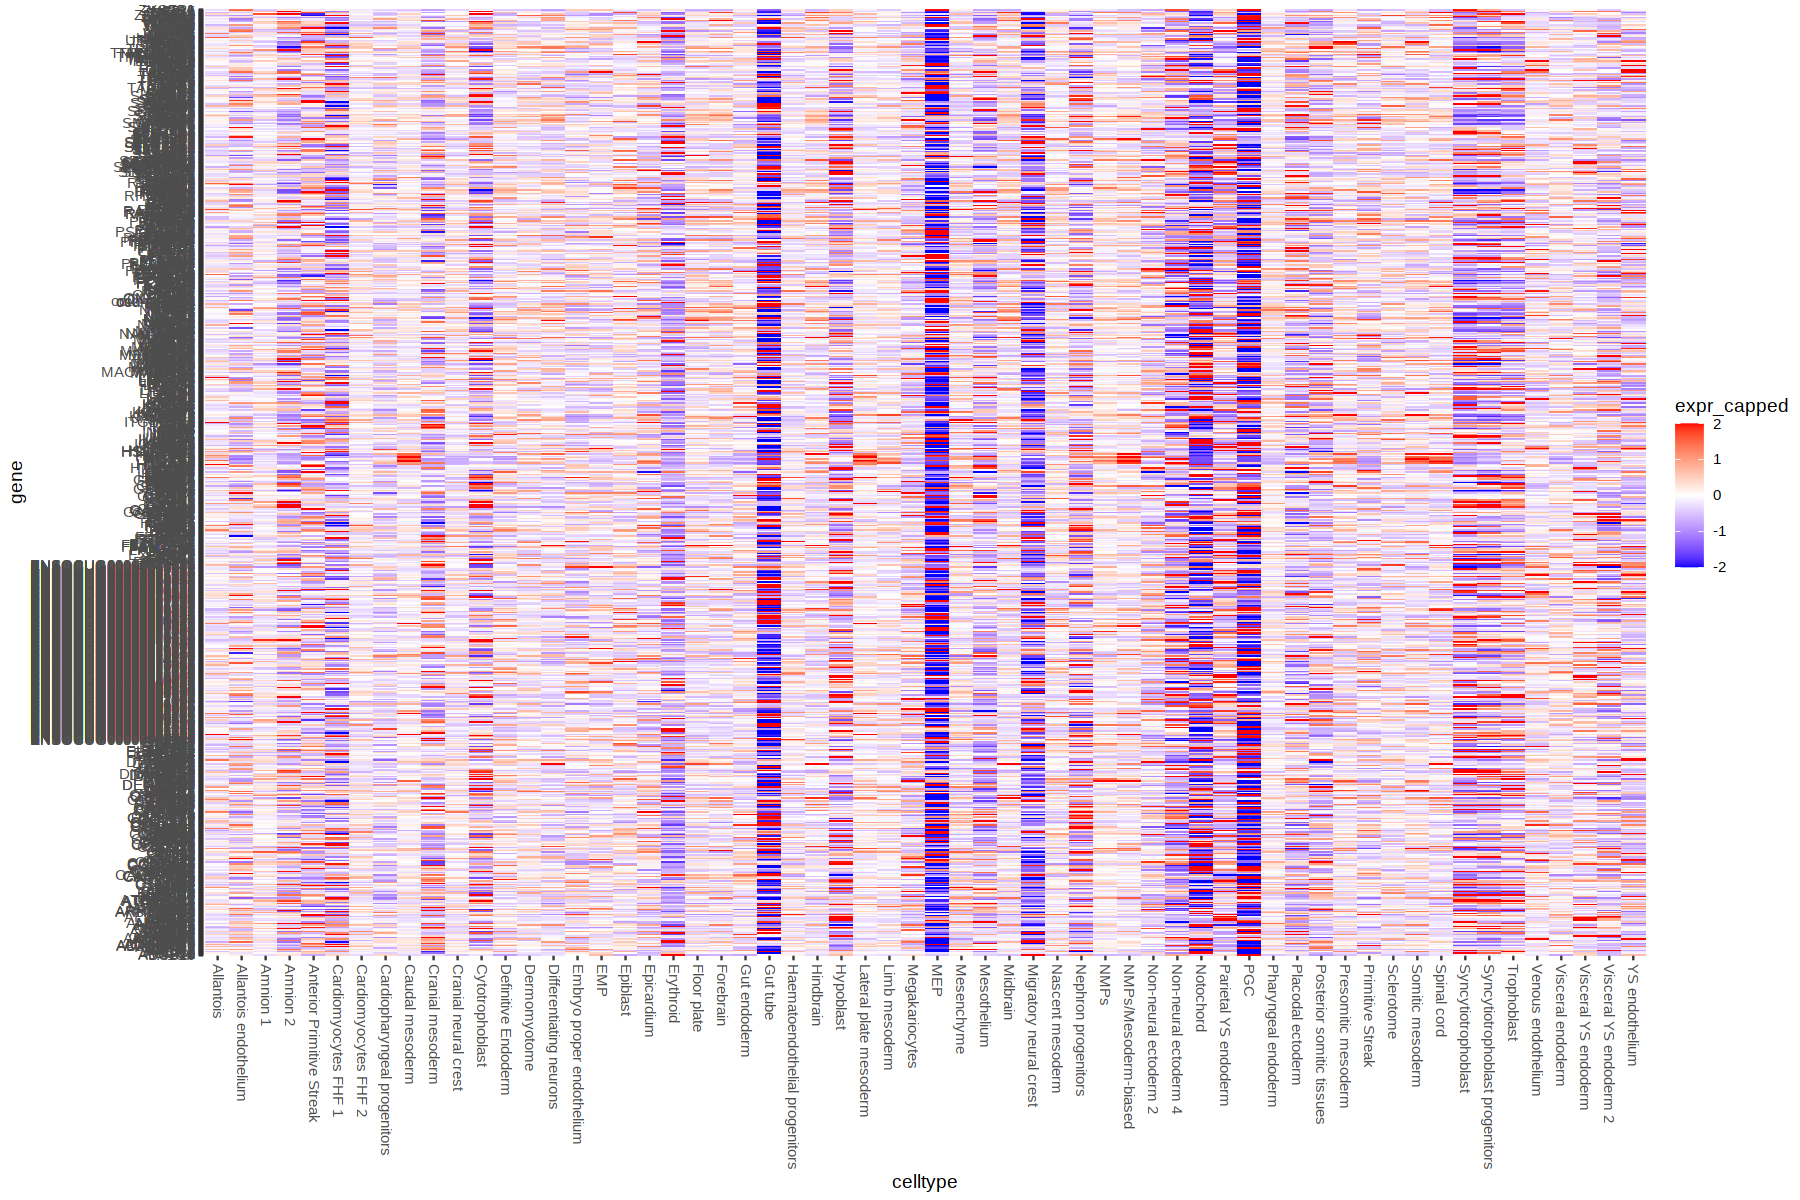

In [109]:
options(repr.plot.width=15, repr.plot.height=10)
ggplot(gene_counts_markers.dt, aes(celltype, gene, fill=expr_capped)) + 
    scale_fill_gradient2(low='blue', high='red') + 
    geom_tile() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5))

In [121]:
expr.mtx = as.data.frame(dcast(gene_counts_markers.dt, celltype ~ gene, value.var = "expr_capped")) %>%
    tibble::column_to_rownames('celltype')

In [123]:
library(ComplexHeatmap)

Warning message:
“The input is a data frame, convert it to a matrix.”


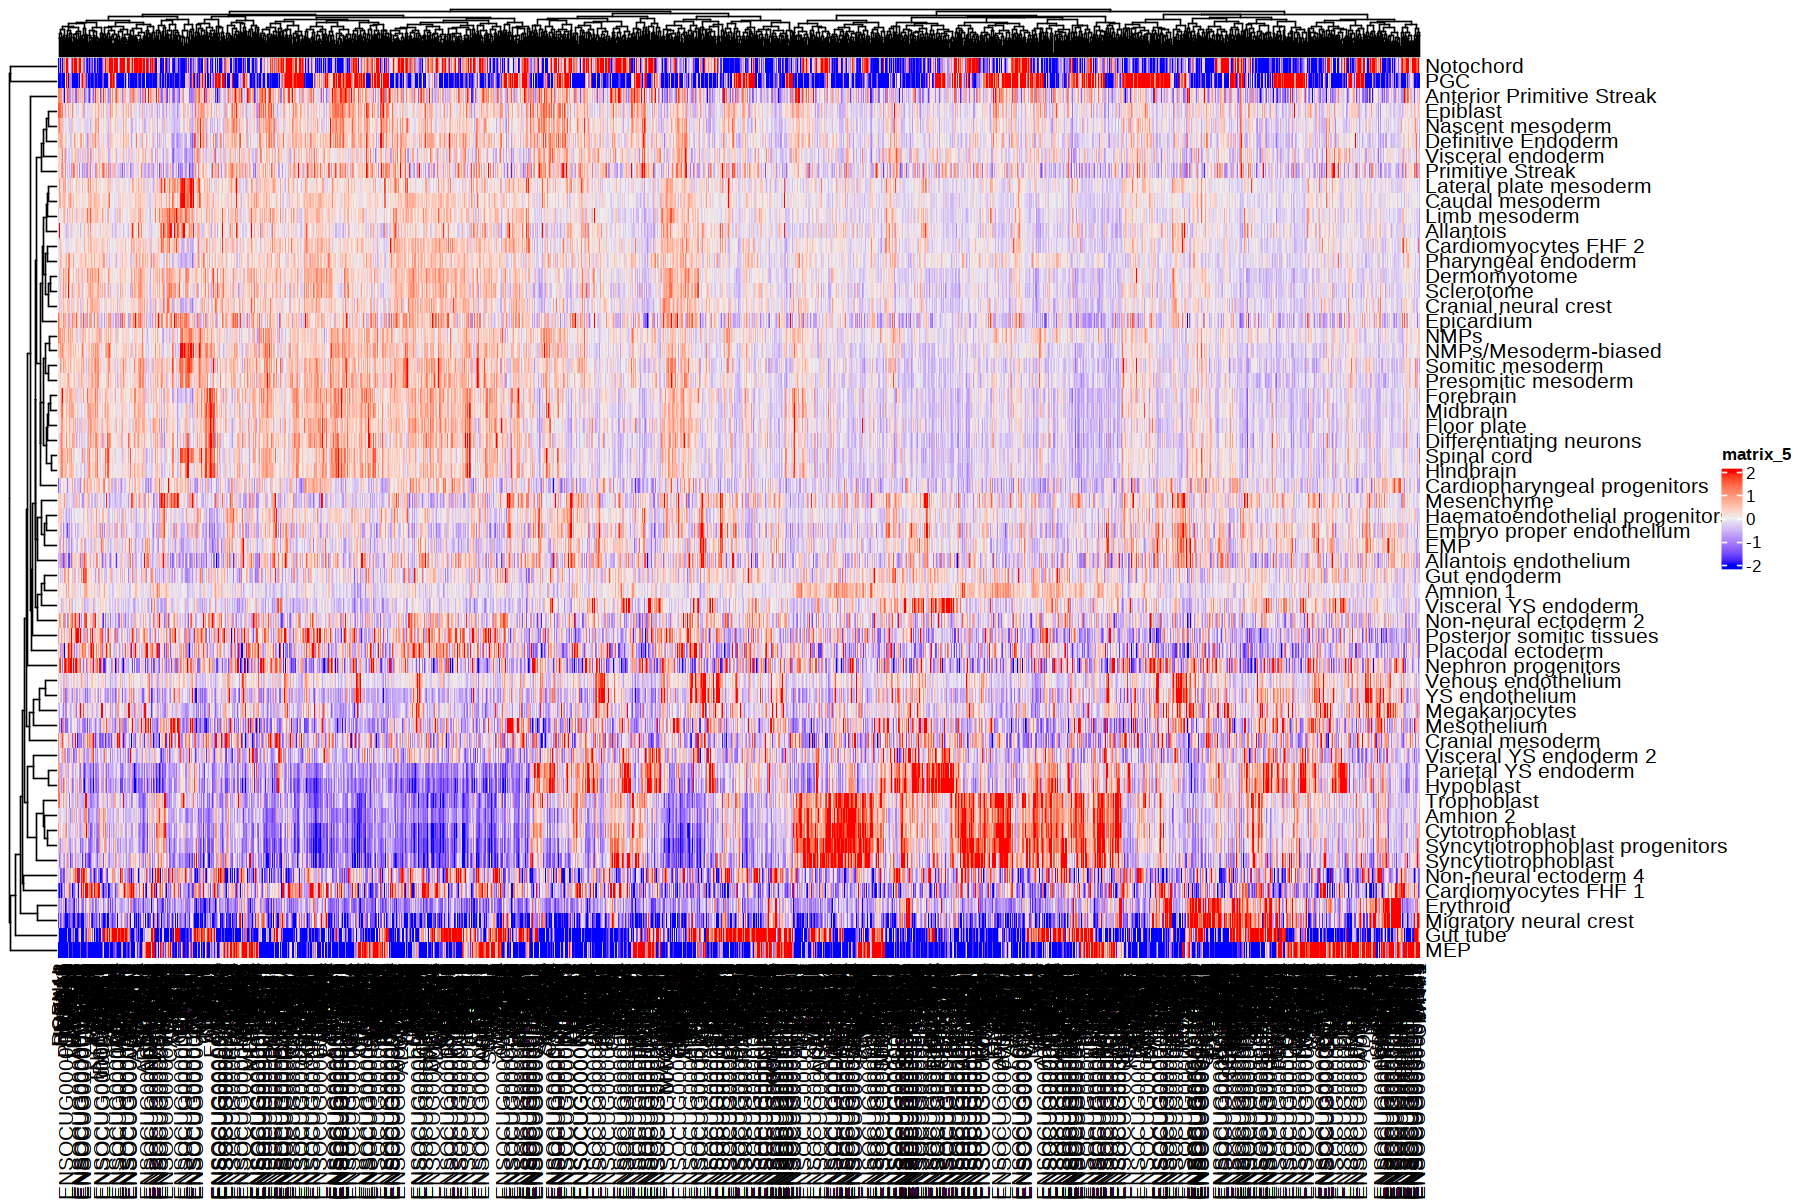

In [124]:
Heatmap(expr.mtx)

In [125]:
head(gene_counts_markers.dt)

celltype,gene,expr,expr_capped
<chr>,<chr>,<dbl>,<dbl>
Allantois,VCAM1,1.4442697,1.4442697
Allantois endothelium,VCAM1,-0.5791792,-0.5791792
Amnion 1,VCAM1,0.2898511,0.2898511
Amnion 2,VCAM1,-0.6719809,-0.6719809
Anterior Primitive Streak,VCAM1,-0.1119131,-0.1119131
Cardiomyocytes FHF 1,VCAM1,-1.1393877,-1.1393877


In [160]:
top_markers = RNA_all_markers[, head(.SD, 3), by='celltype']$gene
top_markers = intersect(top_markers, rownames(gene_counts_pseudobulk))

In [161]:
gene_counts_markers = gene_counts_pseudobulk[unique(top_markers),]

In [162]:
rm_celltypes = c('Hypoblast','Visceral endoderm','Parietal YS endoderm','Visceral YS endoderm','Visceral YS endoderm 2', # hypoblast
                'Trophoblast','Syncytiotrophoblast','Cytotrophoblast','Syncytiotrophoblast progenitors', # trohpoblast
                'Amnion 1','Amnion 2', 'Amnion 3', # Amnion
                'Gut tube', 'PGC', 'Notochord', 'Non-neural ectoderm 4', 'MEP') # test

gene_counts_markers_EP = gene_counts_markers[, !colnames(gene_counts_markers) %in% rm_celltypes]

In [170]:
gene_counts_markers.dt = mclapply(rownames(gene_counts_markers_EP), function(x){
    tmp = data.table(celltype = gene_counts_markers_EP$predictedGroup_celltype_PeakMatrix,
                     gene = x,
                     expr = minmax(as.vector(gene_counts_markers_EP[x,]@assays@data$counts)))
}, mc.cores=16) %>% rbindlist() %>% # setnames('expr.V1', 'expr') %>%
    .[,expr_capped := ifelse(expr<=-2, -2, 
                            ifelse(expr>=2, 2, expr))]
    
    

In [171]:
expr.mtx = as.data.frame(dcast(gene_counts_markers.dt, celltype ~ gene, value.var = "expr_capped")) %>%
    tibble::column_to_rownames('celltype')

Warning message:
“The input is a data frame, convert it to a matrix.”


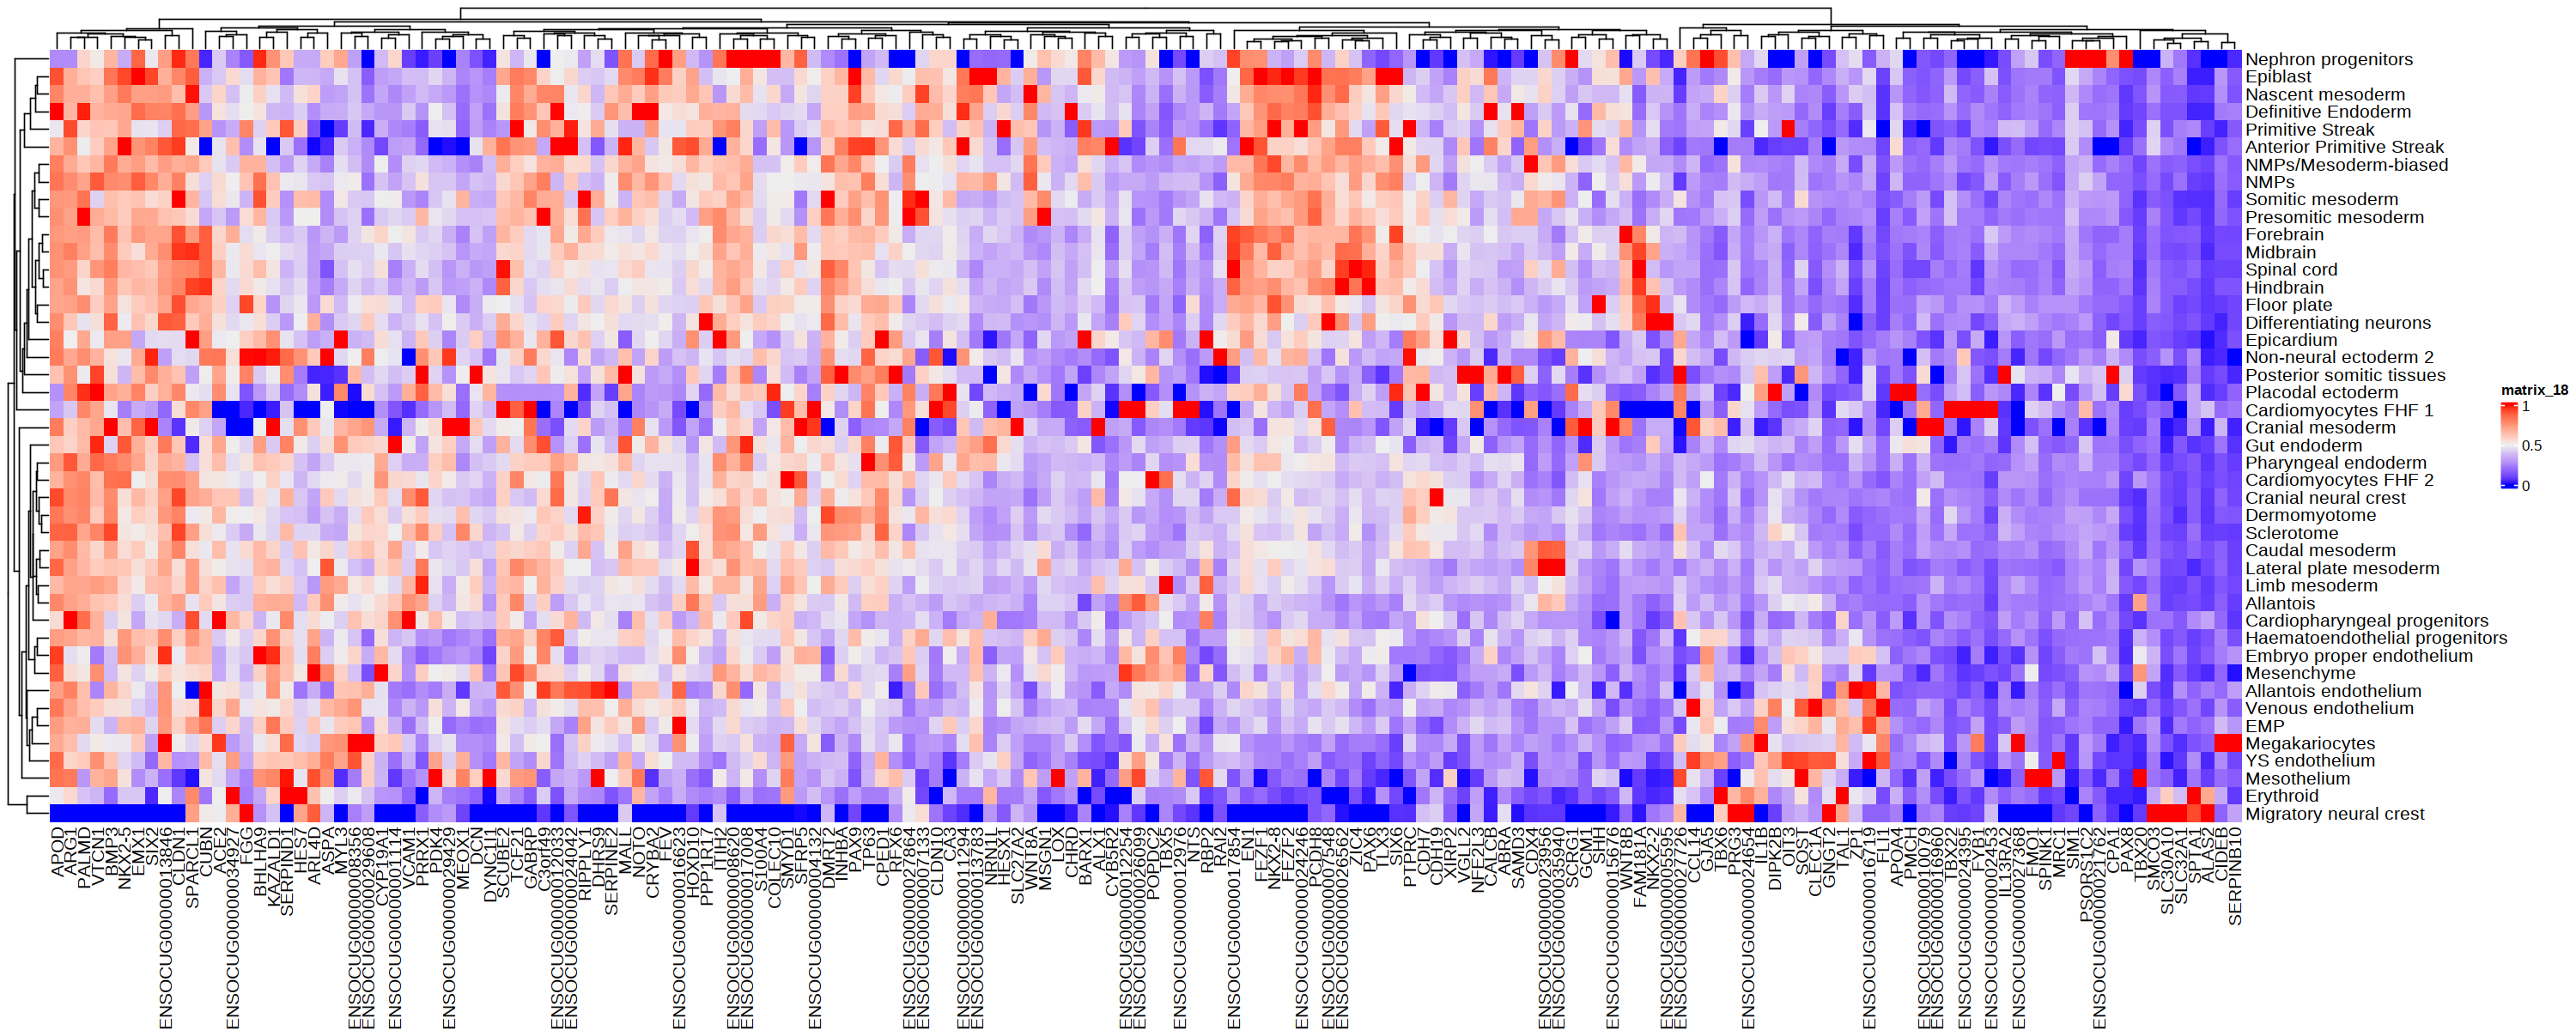

In [172]:
options(repr.plot.width=25, repr.plot.height=10)

Heatmap(expr.mtx)

### Mean score

In [141]:
rm_celltypes = c('Hypoblast','Visceral endoderm','Parietal YS endoderm','Visceral YS endoderm','Visceral YS endoderm 2', # hypoblast
                'Trophoblast','Syncytiotrophoblast','Cytotrophoblast','Syncytiotrophoblast progenitors', # trohpoblast
                'Amnion 1','Amnion 2', 'Amnion 3', # Amnion
                'Gut tube', 'PGC', 'Notochord', 'Non-neural ectoderm 4', 'MEP') # test

gene_counts_pseudobulk_EP = gene_counts_pseudobulk[, !colnames(gene_counts_pseudobulk) %in% rm_celltypes]

In [142]:
counts = gene_counts_pseudobulk_EP@assays@data$counts

In [143]:
counts = apply(counts, 2, scale)
rownames(counts) = rowData(gene_counts_pseudobulk)$name

In [189]:
markers_mean = lapply(unique(RNA_all_markers$celltype), function(x){
        markers_tmp = RNA_all_markers[celltype==x] %>% 
           # .[logFC>2] %>% 
            .[order(-logFC), gene] %>% head(5)
        markers_tmp = intersect(markers_tmp, rownames(atac.mtx))
    

        tmp = data.table(celltype=colnames(counts),
                         celltype_marker = x,
                         #mean_expr = scale(colMeans(counts[markers_tmp,])))
                         mean_expr = colMeans(counts[markers_tmp,]))
}) %>% rbindlist() %>% setnames(c('celltype', 'celltype_marker', 'mean_expr'))

In [174]:
expr.mtx = as.data.frame(dcast(markers_mean, celltype ~ celltype_marker, value.var = "mean_expr.V1")) %>%
    tibble::column_to_rownames('celltype')

Warning message:
“The input is a data frame, convert it to a matrix.”


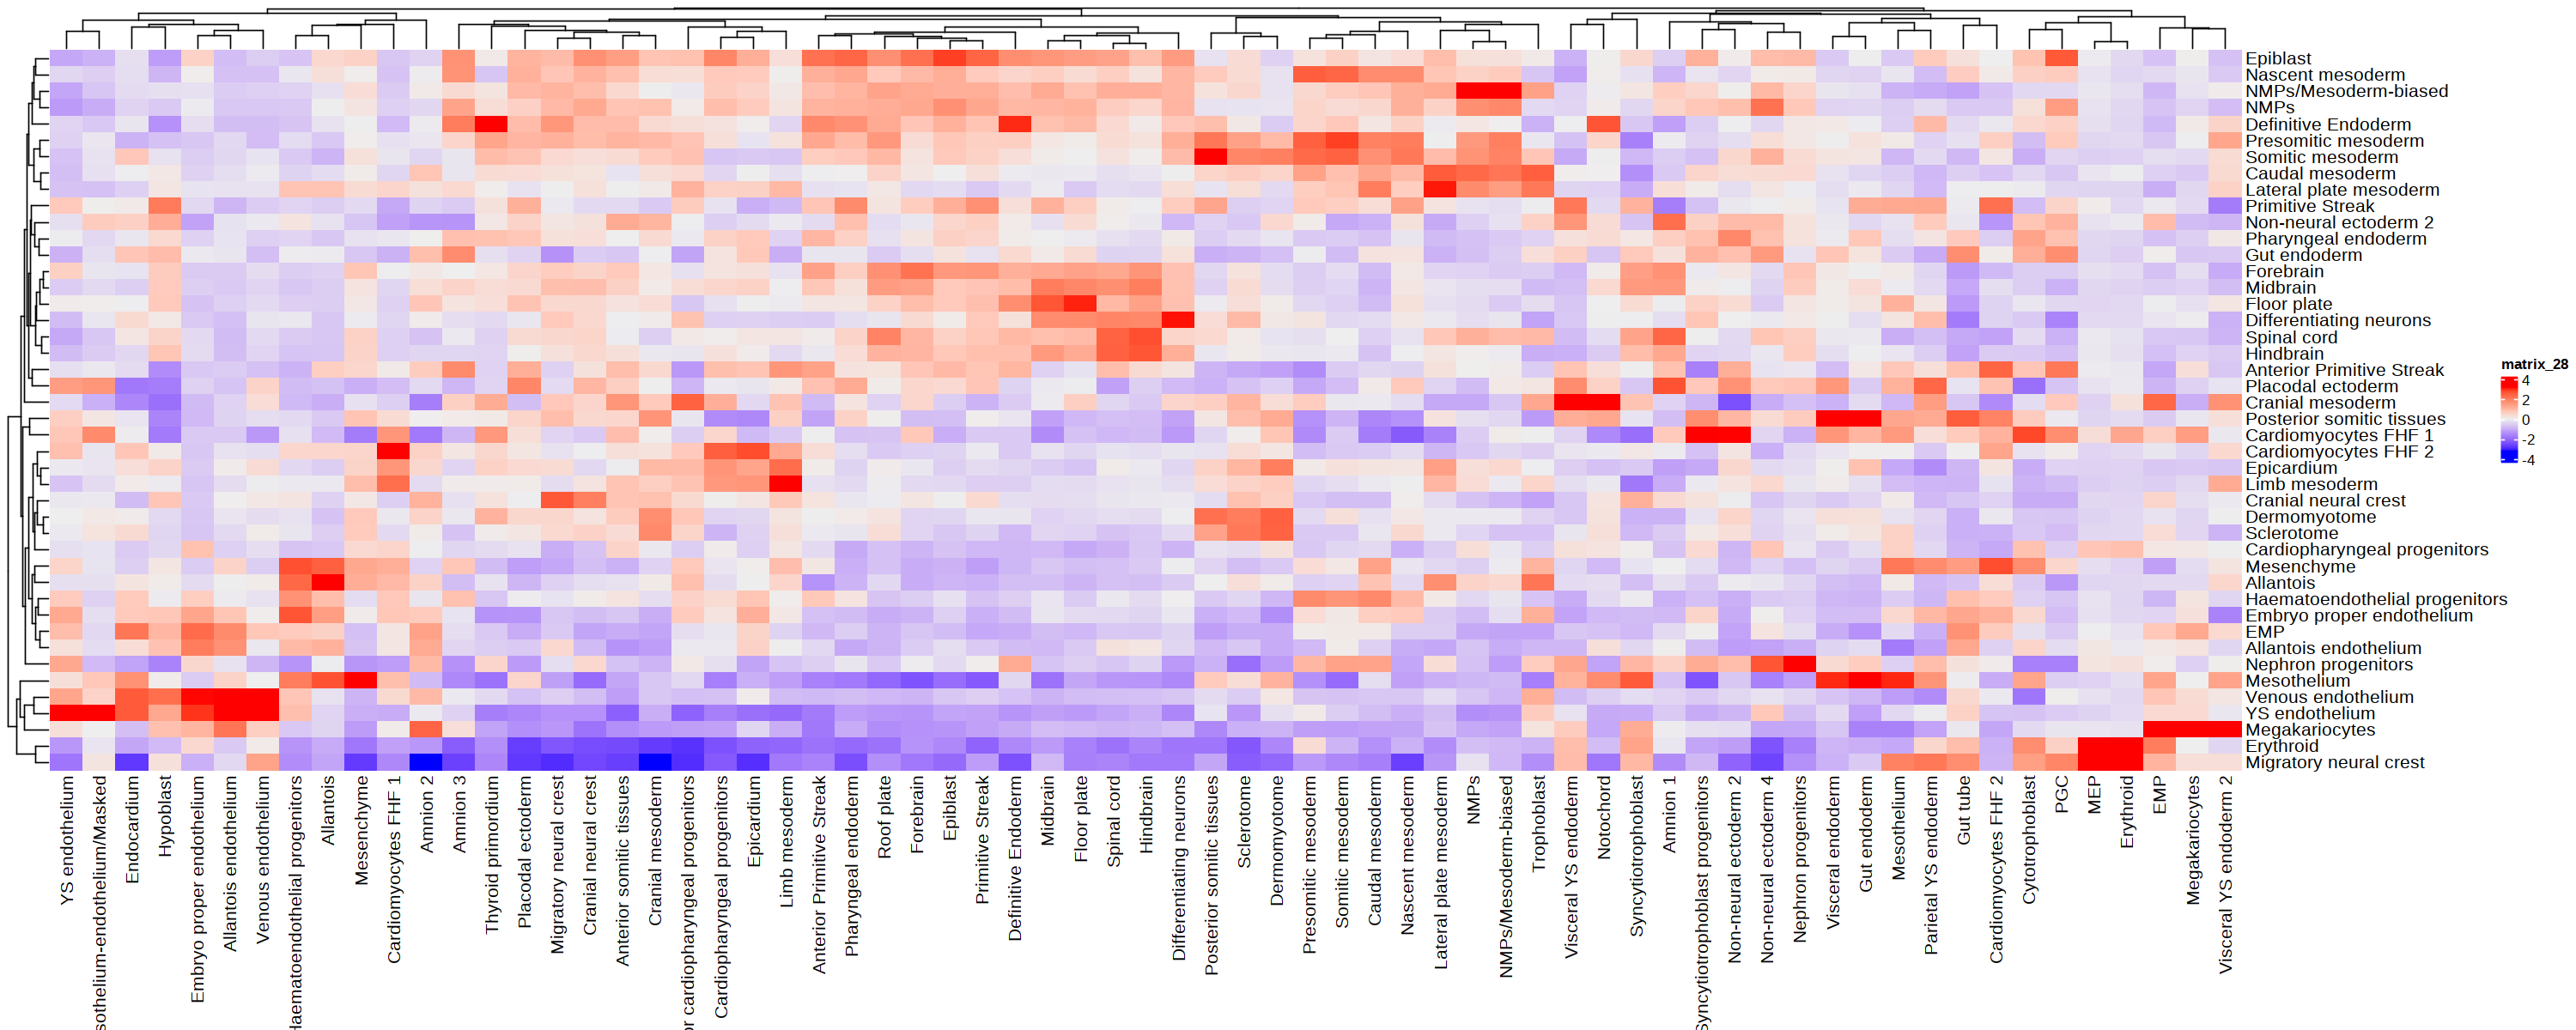

In [175]:
options(repr.plot.width=25, repr.plot.height=10)

Heatmap(expr.mtx)

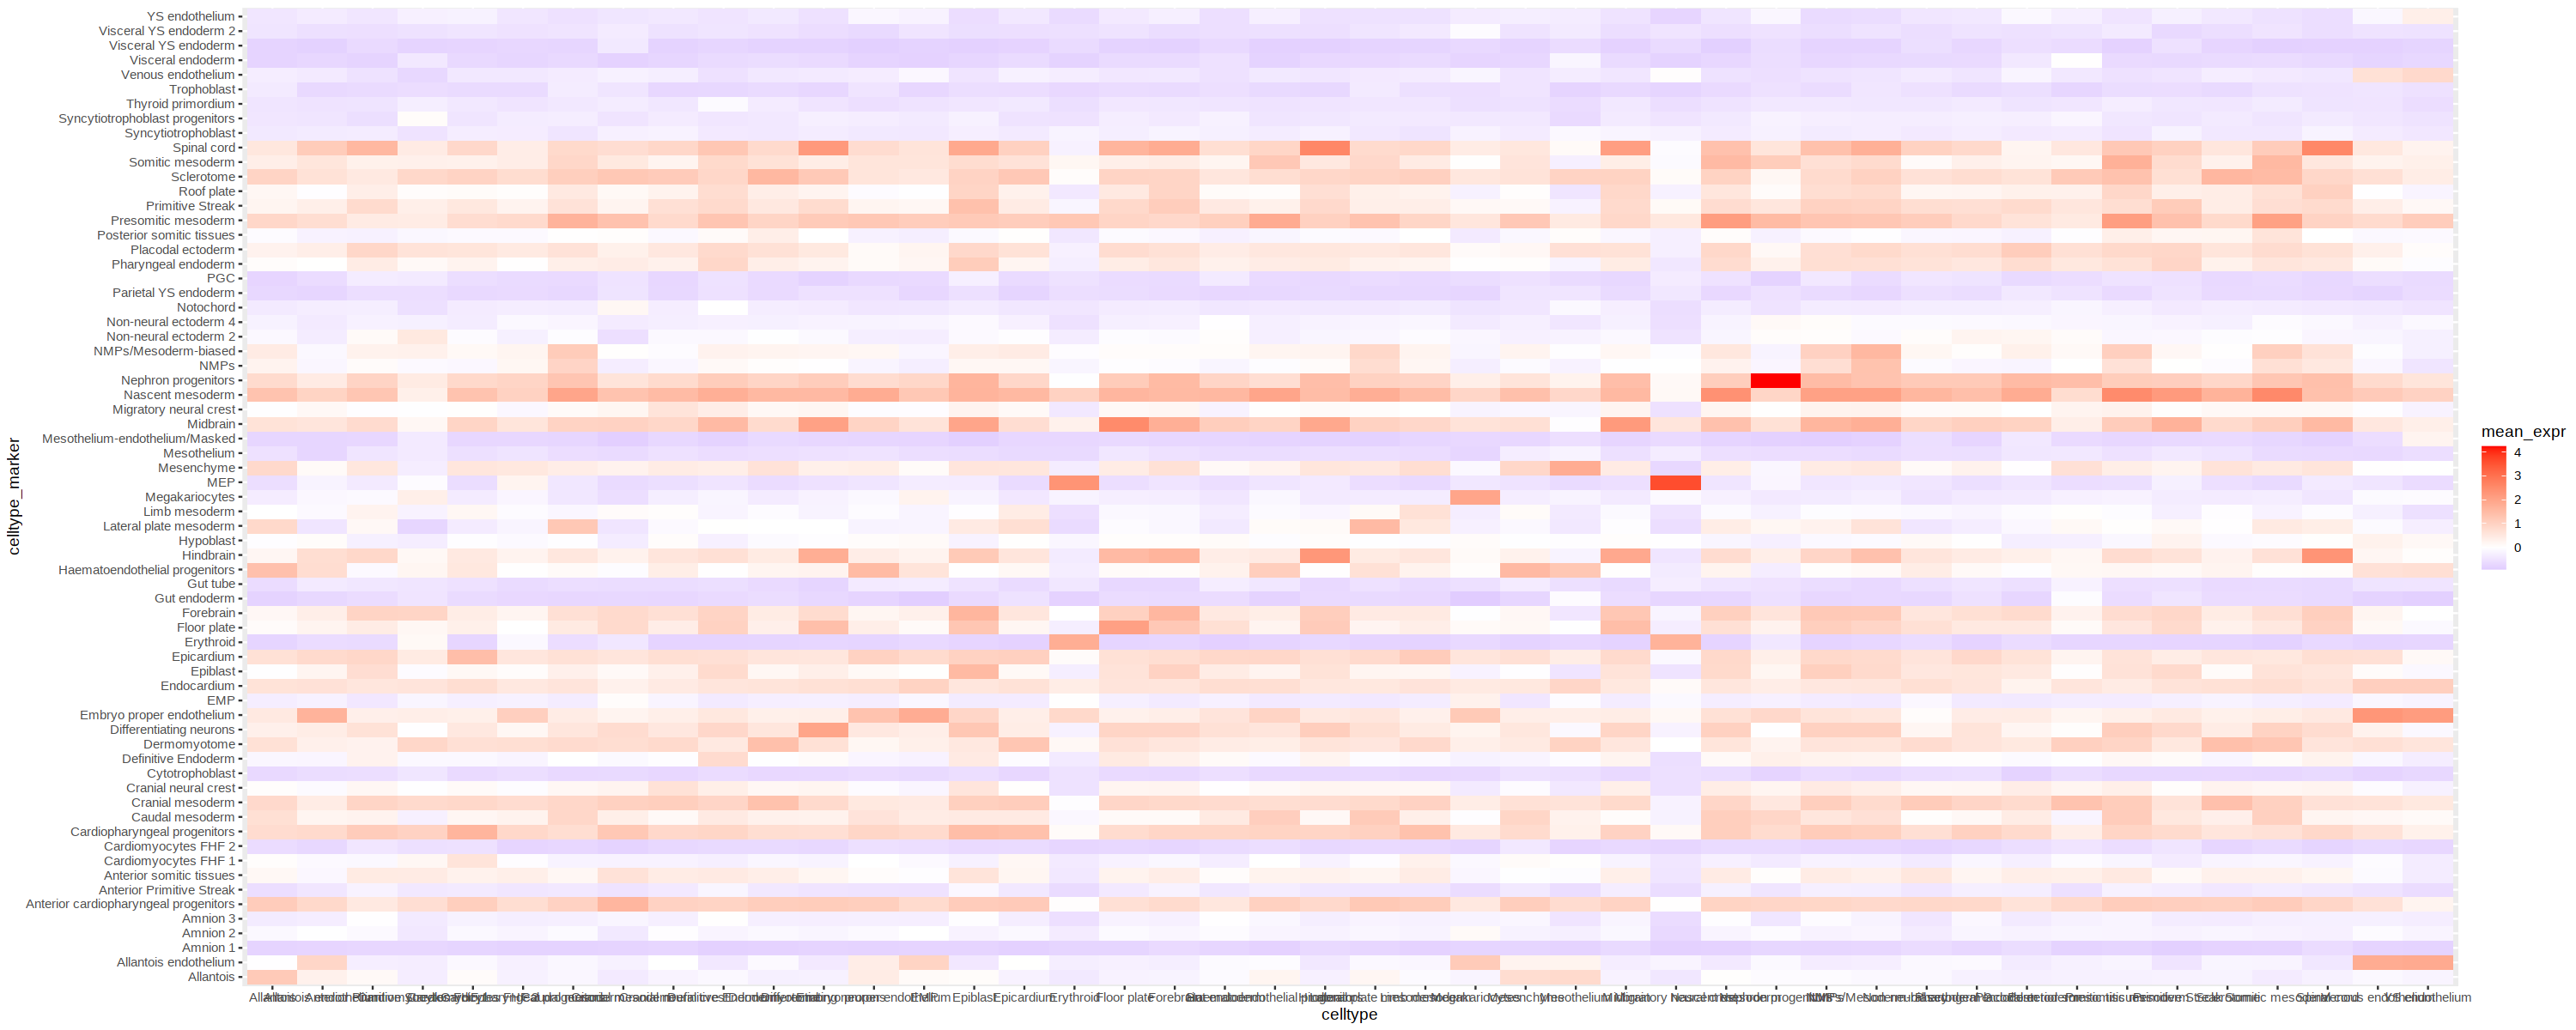

In [190]:
ggplot(markers_mean, aes(celltype, celltype_marker, fill=mean_expr)) + geom_tile() + scale_fill_gradient2(low='blue', high='red')

In [ ]:
# mean of top marker genes
mclapply(rownames(gene_counts_markers_EP), function(x){
    tmp = data.table(celltype = gene_counts_markers_EP$predictedGroup_celltype_PeakMatrix,
                     gene = x,
                     expr = minmax(as.vector(gene_counts_markers_EP[x,]@assays@data$counts)))
}, mc.cores=16) %>% rbindlist() %>% # setnames('expr.V1', 'expr') %>%
    .[,expr_capped := ifelse(expr<=-2, -2, 
                            ifelse(expr>=2, 2, expr))]

In [29]:
x = 'VCAM1'


In [30]:
head(tmp)

celltype,gene,expr
<chr>,<chr>,<dbl>
Hypoblast,VCAM1,0.000
Haematoendothelial progenitors,VCAM1,0.596
Nascent mesoderm,VCAM1,0.030
Epiblast,VCAM1,0.032
Epiblast,VCAM1,0.130
Epiblast,VCAM1,0.064
